# TP2 — Influencia de las estrategias de muestreo

**Caso de estudio: reconstrucción del campo de flujo en una cavidad cuadrada (*lid-driven cavity*), Re = 100.**

Redes Neuronales Informadas por Física — Esp. en Inteligencia Artificial, FIUBA, 2026B3.

---

En el TP1 el muestreo de puntos de colocación fue **aleatorio uniforme**, sorteado una única vez y congelado
durante todo el entrenamiento. El análisis crítico de ese trabajo identificó dos consecuencias de esa decisión:

1. El error se concentró donde el muestreo uniforme cubre peor: la capa límite bajo la tapa y las esquinas.
2. El modelo minimizó **una realización particular** del estimador de Monte Carlo en lugar de la integral del
   residuo, con la consecuencia de que la pérdida dejó de ser un indicador confiable de la calidad de la solución.

Este TP ataca exactamente eso. Se comparan cuatro estrategias de muestreo bajo un presupuesto de cómputo idéntico
(50 000 épocas y la misma arquitectura en todos los casos):

| Estrategia | Puntos | Idea |
|---|---|---|
| **Baseline LHS** | 10 000 fijos | Muestreo estratificado, sin adaptación |
| **RAR-D — A** ($k=1$, $c=1$) | 5 000 → 9 000 | Valores por defecto de Wu et al. |
| **RAR-D — B** ($k=2$, $c=0$) | 5 000 → 9 000 | Alta explotación: sesgo fuerte al residuo alto |
| **RAR-D — C** ($k=1$, $c=3$) | 5 000 → 9 000 | Alta exploración: se aproxima a muestreo aleatorio |

## Mapa de consignas

| Sección | Contenido |
|---|---|
| 2 | Núcleo heredado del TP1 (arquitectura, residuos, pérdida, evaluación) |
| 3 | Modos de falla de las PINN: qué ataca el muestreo y qué queda fuera (Lectura 3.1) |
| 4 | Estrategias de muestreo: el mapa completo (Lectura 4.1) y el baseline LHS |
| 5 | **Consigna 1** — Baseline: $N_{\rm pde}=10\,000$, $N_{\rm bc}=1000$, $\lambda_{\rm bc}=10$, $\lambda_p=100$, 50 000 épocas |
| 6 | **Consigna 2** — Implementación de RAR-D en las tres configuraciones |
| 7 | **Consigna 3** — Norma-2 del error, tiempo total de entrenamiento y discusión |

Las secciones 3 y 4 son el marco teórico: la primera ubica al muestreo dentro del cuadro de modos de falla de la
Lectura 3.1 —para poder distinguir, en la discusión final, lo que una estrategia de muestreo puede arreglar de lo
que no—, y la segunda despliega la taxonomía de estrategias de la Lectura 4.1, de la cual el enunciado selecciona
dos: LHS como baseline no adaptativo y RAR-D como estrategia adaptativa.

In [ ]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
from scipy.stats import qmc

# ----------------------------------------------------------------------------- reproducibilidad
SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------------------------- dispositivo
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
DTYPE = torch.float32
torch.set_default_dtype(DTYPE)

# ----------------------------------------------------------------------------- configuración
RE = 100.0

# Hiperparametros fijados por el enunciado
N_PDE_BASE = 10_000       # puntos de colocacion del baseline
N_BC = 1_000              # puntos de las condiciones de borde (todas las configuraciones)
LAMBDA_BC = 10.0
LAMBDA_P = 100.0
EPOCHS_TOTAL = 50_000     # presupuesto de epocas, identico en todas las configuraciones

# Esquema RAR-D
N_PDE_INIT = 5_000        # muestreo LHS inicial
N_ROUNDS = 4              # rondas de refinamiento
N_ADD = 1_000             # puntos agregados por ronda
POOL_SIZE = 20_000        # |S_0|, pool de candidatos fijo
EPOCHS_PER_ROUND = 10_000 # 10_000 iniciales + 4 x 10_000 = 50_000

# Arquitectura y optimizacion (identicas en todas las configuraciones, por el enunciado)
LAYERS = [2] + [64] * 5 + [3]
LR = 1e-3
LR_STEP, LR_GAMMA = 10_000, 0.5
LOG_EVERY = 1_000

DATA_DIR = Path("Re-100")
FIG_DIR = Path("figs_tp2")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})

print(f"torch {torch.__version__} | dispositivo: {DEVICE}")
print(f"presupuesto: {EPOCHS_TOTAL:,} épocas por configuración | arquitectura: "
      f"{len(LAYERS) - 2} capas x {LAYERS[1]} neuronas")

torch 2.13.0 | dispositivo: mps
presupuesto: 50,000 épocas por configuración | arquitectura: 5 capas x 64 neuronas


---
# 2. Núcleo heredado del TP1

Se reutiliza sin cambios la maquinaria desarrollada en el TP1: arquitectura, cómputo de residuos por
autodiferenciación, función de pérdida, loop de entrenamiento y rutinas de evaluación contra la solución MEF de
referencia. El notebook se mantiene **autocontenido** —el código está replicado, no importado— para que pueda
ejecutarse de forma independiente.

Las dos únicas diferencias respecto del TP1 son las que impone el enunciado: los pesos de la pérdida
($\lambda_{\rm bc}=10$, $\lambda_p=100$; en el TP1 eran $10$ y $1$) y el presupuesto de 50 000 épocas.

## Por qué 5 capas × 64 neuronas

El enunciado deja la arquitectura a criterio, pidiendo "no elevar el costo computacional más allá de sus recursos
disponibles". Se mantiene la del TP1, y la elección está respaldada por el barrido del **Anexo B** de ese trabajo,
donde se entrenaron cinco arquitecturas variando únicamente profundidad y ancho:

| Arquitectura | Params | rel $u$ | rel $v$ |
|---|---|---|---|
| 4×20 *(cátedra, heat)* | 1 383 | 42,6 % | 87,9 % |
| 8×20 *(cátedra, burgers)* | 3 063 | 39,3 % | 76,4 % |
| 4×40 | 5 163 | 24,1 % | 44,8 % |
| **5×64** | 17 027 | **21,1 %** | **36,2 %** |
| 6×128 | 83 331 | 21,3 % | 36,4 % |

5×64 es la arquitectura **más chica que alcanza la meseta**: quintuplicar los parámetros no mejora nada, y
reducirla a 4×40 cuesta tres puntos en $u$ y nueve en $v$. Como cada configuración de este TP entrena 50 000
épocas y hay cuatro configuraciones, la diferencia de costo entre arquitecturas es de decenas de minutos: 4×40
habría recortado el total a la mitad, pero pagando esa pérdida de precisión

In [2]:
class PINN(nn.Module):
    """Red densa con normalizacion de entrada al hipercubo [-1,1] (idéntica al TP1).

    Unica diferencia de implementacion respecto del TP1: la normalizacion se hace con
    escalares de Python en lugar de buffers de forma (2,). Es matematicamente identico
    -el dominio es el cuadrado unitario, con lo cual ambos ejes comparten escala- pero
    un buffer (2,) difundido rompe el trazado de torch.compile bajo jvp anidado: los
    tangentes del buffer quedan con stride 0 y el trazador falla con
    'more than one element of the written-to tensor refers to a single memory location'.
    """

    def __init__(self, layers, lb=(0.0, 0.0), ub=(1.0, 1.0), activation=nn.Tanh):
        super().__init__()
        assert lb[0] == lb[1] and ub[0] == ub[1], "se asume dominio cuadrado"
        self.scale = 2.0 / (ub[0] - lb[0])
        self.shift = -2.0 * lb[0] / (ub[0] - lb[0]) - 1.0
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(activation())
        self.net = nn.Sequential(*mods)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain("tanh"))
            nn.init.zeros_(m.bias)

    def forward(self, xy):
        return self.net(self.scale * xy + self.shift)


def d(f, x):
    """Gradiente de f respecto de x, manteniendo el grafo para derivadas de orden superior."""
    return torch.autograd.grad(f, x, grad_outputs=torch.ones_like(f), create_graph=True)[0]


def pde_residuals_reverse(model, xy, Re=RE):
    """Residuos por autodiferenciacion en modo REVERSO (implementacion del TP1).

    Es la version canonica, equivalente a `governingEquationResidue` de las notebooks
    de la catedra. Se conserva como referencia y para la verificacion de equivalencia.
    """
    xy = xy.clone().requires_grad_(True)
    out = model(xy)
    u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]

    du, dv, dp = d(u, xy), d(v, xy), d(p, xy)
    u_x, u_y = du[:, 0:1], du[:, 1:2]
    v_x, v_y = dv[:, 0:1], dv[:, 1:2]
    p_x, p_y = dp[:, 0:1], dp[:, 1:2]

    u_xx = d(u_x, xy)[:, 0:1]
    u_yy = d(u_y, xy)[:, 1:2]
    v_xx = d(v_x, xy)[:, 0:1]
    v_yy = d(v_y, xy)[:, 1:2]

    r_x = u * u_x + v * u_y + p_x - (u_xx + u_yy) / Re
    r_y = u * v_x + v * v_y + p_y - (v_xx + v_yy) / Re
    r_c = u_x + v_y
    return r_x, r_y, r_c

### Cómputo de los residuos en modo *forward*

El TP2 exige 50 000 épocas en cuatro configuraciones, de modo que el costo de cada paso importa. El modo reverso
necesita **7 llamadas a `autograd.grad`** por paso: tres para las primeras derivadas de $\hat u,\hat v,\hat p$ y
cuatro para las segundas. Eso es lo apropiado cuando hay pocas salidas y muchas entradas — el caso del
entrenamiento respecto de los pesos—, pero acá las derivadas se toman respecto de **sólo dos variables**, $(x,y)$.

En ese régimen conviene el **modo forward**: una pasada con vector tangente $\boldsymbol{e}_1=(1,0)$ propaga
simultáneamente $\partial_x$ de las tres salidas, y anidándola consigo misma se obtiene además $\partial_{xx}$.
Con dos pasadas anidadas —una por cada eje— se consigue todo lo necesario:

| Pasada | Entrega |
|---|---|
| Anidada con $\boldsymbol{e}_1=(1,0)$ | $\hat u,\hat v,\hat p$; $\ \partial_x$ de las tres; $\ \partial_{xx}$ de las tres |
| Anidada con $\boldsymbol{e}_2=(0,1)$ | $\partial_y$ de las tres; $\ \partial_{yy}$ de las tres |


In [ ]:
def _nested_jvp(fn, xy, e):
    """Pasada forward anidada: devuelve (f, df/de, d2f/de2) a lo largo de la direccion e."""
    g = lambda x: torch.func.jvp(fn, (x,), (e,))
    (out, d1), (_, d2) = torch.func.jvp(g, (xy,), (e,))
    return out, d1, d2


def pde_residuals_forward(model, xy, Re=RE):
    """Residuos por autodiferenciacion en modo FORWARD. Matematicamente identico a
    `pde_residuals_reverse`, con 2 pasadas anidadas en lugar de 7 llamadas de autograd."""
    e_x = torch.zeros_like(xy); e_x[:, 0] = 1.0
    e_y = torch.zeros_like(xy); e_y[:, 1] = 1.0

    out, dx, dxx = _nested_jvp(model, xy, e_x)      # valores, d/dx, d2/dx2
    _, dy, dyy = _nested_jvp(model, xy, e_y)        #          d/dy, d2/dy2

    u, v = out[:, 0:1], out[:, 1:2]
    u_x, v_x, p_x = dx[:, 0:1], dx[:, 1:2], dx[:, 2:3]
    u_y, v_y, p_y = dy[:, 0:1], dy[:, 1:2], dy[:, 2:3]

    r_x = u * u_x + v * u_y + p_x - (dxx[:, 0:1] + dyy[:, 0:1]) / Re
    r_y = u * v_x + v * v_y + p_y - (dxx[:, 1:2] + dyy[:, 1:2]) / Re
    r_c = u_x + v_y
    return r_x, r_y, r_c


USE_COMPILE = True  


def pde_residuals(model, xy, Re=RE):
    """Residuos, por el camino mas rapido disponible.

    `torch.compile` se aplica sobre una funcion que *cierra* sobre el modelo y recibe
    unicamente el tensor de puntos: pasar el modulo como argumento hace fallar el
    trazado. La funcion compilada se guarda como atributo **del propio modelo**, de
    modo que su ciclo de vida quede atado al del modelo (usar un diccionario indexado
    por `id(model)` seria incorrecto: CPython reutiliza direcciones tras liberar un
    objeto, y una configuracion podria terminar usando la funcion compilada de otra).

    Si la compilacion falla en este equipo, se degrada a modo eager sin interrumpir
    el trabajo.
    """
    if not USE_COMPILE:
        return pde_residuals_forward(model, xy, Re)
    fn = getattr(model, "_compiled_residuals", None)
    if fn is None:
        fn = torch.compile(lambda x: pde_residuals_forward(model, x, Re))
        object.__setattr__(model, "_compiled_residuals", fn)
    try:
        return fn(xy)
    except Exception as exc:                      # noqa: BLE001
        print(f"[aviso] torch.compile falló ({type(exc).__name__}), se continúa en modo eager")
        fn = lambda x: pde_residuals_forward(model, x, Re)   # noqa: E731
        object.__setattr__(model, "_compiled_residuals", fn)
        return fn(xy)

In [ ]:
check_model = PINN(LAYERS).to(DEVICE)
xy_chk = torch.rand(1_000, 2, device=DEVICE)

r_rev = pde_residuals_reverse(check_model, xy_chk)
r_fwd = pde_residuals(check_model, xy_chk)

print("Residuos — modo forward vs. modo reverso (máx. diferencia absoluta):")
for name, a, b in zip(("r_x", "r_y", "r_c"), r_rev, r_fwd):
    print(f"  {name}: {(a - b).abs().max().item():.2e}   (escala típica |{name}| ~ "
          f"{a.abs().mean().item():.2e})")

grads = []
for residual_fn in (pde_residuals_reverse, pde_residuals):
    check_model.zero_grad()
    sum(r.pow(2).mean() for r in residual_fn(check_model, xy_chk)).backward()
    grads.append(torch.cat([p.grad.flatten() for p in check_model.parameters()]).clone())

print(f"\nGradientes respecto de los 17 027 parámetros: "
      f"máx. diferencia = {(grads[0] - grads[1]).abs().max().item():.2e}")
print("Ambas diferencias están en el nivel de redondeo de float32 (~1e-6 relativo): las dos\n"
      "implementaciones calculan la misma derivada exacta.")

Residuos — modo forward vs. modo reverso (máx. diferencia absoluta):
  r_x: 1.53e-05   (escala típica |r_x| ~ 5.91e+00)
  r_y: 1.42e-05   (escala típica |r_y| ~ 1.71e+00)
  r_c: 1.14e-05   (escala típica |r_c| ~ 4.75e+00)

Gradientes respecto de los 17 027 parámetros: máx. diferencia = 5.72e-05
Ambas diferencias están en el nivel de redondeo de float32 (~1e-6 relativo): las dos
implementaciones calculan la misma derivada exacta.


In [ ]:
def pack_bc(ds):
    """Concatena las cuatro paredes y el anclaje en un unico tensor de entrada."""
    keys = sorted(k for k in ds if k.startswith("bc_"))
    bounds = np.cumsum([0] + [len(ds[k]["xy"]) for k in keys])
    return {
        "xy": torch.cat([ds[k]["xy"] for k in keys] + [ds["anchor"]["xy"]]),
        "uv": torch.cat([ds[k]["uv"] for k in keys]),
        "n_bc": int(bounds[-1]),
        "keys": keys,
        "bounds": bounds,
    }


def compute_losses(model, ds, bc, Re=RE):
    """Contribuciones de cada sub-conjunto a la funcion de perdida."""
    r_x, r_y, r_c = pde_residuals(model, ds["pde"]["xy"], Re)
    L = {"pde_x": r_x.pow(2).mean(), "pde_y": r_y.pow(2).mean(), "pde_c": r_c.pow(2).mean()}
    out = model(bc["xy"])
    se = (out[:bc["n_bc"], 0:2] - bc["uv"]).pow(2).mean(dim=1)
    for k, a, b in zip(bc["keys"], bc["bounds"][:-1], bc["bounds"][1:]):
        L[k] = se[a:b].mean()
    L["anchor"] = (out[bc["n_bc"]:, 2:3] - ds["anchor"]["p"]).pow(2).mean()
    return L


def total_loss(L):
    """Suma ponderada, con los pesos que fija el enunciado del TP2."""
    pde = L["pde_x"] + L["pde_y"] + L["pde_c"]
    bc = sum(v for k, v in L.items() if k.startswith("bc_")) / 4.0
    return pde + LAMBDA_BC * bc + LAMBDA_P * L["anchor"], pde, bc


def new_optimizer(model):
    """Adam + decaimiento por pasos. Se crea una sola vez por configuracion, de modo que
    el estado del optimizador y el schedule del learning rate son continuos a lo largo de
    todas las rondas de RAR-D (y equivalentes a los del baseline)."""
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=0.0)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=LR_STEP, gamma=LR_GAMMA)
    return opt, sched


def train(model, ds, epochs, opt, sched, hist=None, epoch0=0, log_every=LOG_EVERY, tag=""):
    """Loop de entrenamiento a lote completo. Devuelve el historial y el tiempo insumido.

    Puede invocarse varias veces sobre el mismo modelo/optimizador para encadenar las
    rondas de RAR-D, acumulando en el mismo `hist`.
    """
    model.train()
    bc_pack = pack_bc(ds)
    keys = ["epoch", "total", "pde", "bc", "anchor", "pde_x", "pde_y", "pde_c", "n_pde", "lr"]
    hist = hist if hist is not None else {k: [] for k in keys}
    t0 = t_prev = time.time()
    n_pde = len(ds["pde"]["xy"])
    if tag:
        print(f"\n--- {tag} | N_pde = {n_pde:,} | {epochs:,} épocas ---")
        print(f"{'época':>8} {'total':>11} {'L_pde':>11} {'L_bc':>11} {'L_anchor':>11} "
              f"{'lr':>9} {'t[s]':>8} {'it/s':>7}")
    for ep in range(epochs):
        L = compute_losses(model, ds, bc_pack)
        loss, pde, bc = total_loss(L)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        sched.step()

        if ep % log_every == 0 or ep == epochs - 1:
            now = time.time()
            rate = log_every / (now - t_prev) if ep else float("nan")
            t_prev = now
            for k, val in [("epoch", epoch0 + ep), ("total", loss.item()), ("pde", pde.item()),
                           ("bc", bc.item()), ("anchor", L["anchor"].item()),
                           ("pde_x", L["pde_x"].item()), ("pde_y", L["pde_y"].item()),
                           ("pde_c", L["pde_c"].item()), ("n_pde", n_pde),
                           ("lr", sched.get_last_lr()[0])]:
                hist[k].append(val)
            if tag:
                print(f"{epoch0 + ep:>8d} {loss.item():>11.4e} {pde.item():>11.4e} {bc.item():>11.4e} "
                      f"{L['anchor'].item():>11.4e} {sched.get_last_lr()[0]:>9.2e} "
                      f"{now - t0:>8.1f} {rate:>7.1f}", flush=True)
    return hist, time.time() - t0

## Solución de referencia y métricas de error

Idénticas al TP1: se predice sobre los 20 201 nodos de la malla MEF y se reporta la norma-2 del error, absoluta y
relativa, con la tabla adicional que excluye un entorno de las dos esquinas singulares de la tapa.

In [6]:
def load_reference(folder=DATA_DIR):
    """Carga la solucion MEF de referencia (nube de nodos dispersa)."""
    P = sio.loadmat(folder / "pressure.mat")
    V = sio.loadmat(folder / "velocity.mat")
    x, y = P["x"].ravel(), P["y"].ravel()
    assert np.allclose(x, V["x"].ravel()) and np.allclose(y, V["y"].ravel())
    return {"x": x, "y": y, "u": V["u"].ravel(), "v": V["v"].ravel(), "p": P["p"].ravel()}


def structured_grid(ref, h=0.01):
    """Extrae la sub-malla estructurada de vertices (paso h) como arrays 2D."""
    on_node = lambda a: np.abs(a / h - np.round(a / h)) < 1e-9
    m = on_node(ref["x"]) & on_node(ref["y"])
    ix = np.round(ref["x"][m] / h).astype(int)
    iy = np.round(ref["y"][m] / h).astype(int)
    nx, ny = ix.max() + 1, iy.max() + 1
    out = {"x": np.linspace(0, 1, nx), "y": np.linspace(0, 1, ny)}
    for k in ("u", "v", "p"):
        A = np.full((ny, nx), np.nan)
        A[iy, ix] = ref[k][m]
        out[k] = A
    return out


@torch.no_grad()
def predict(model, x, y, batch=50_000):
    """Evalua la red en una nube de puntos y devuelve (u, v, p) como arrays de numpy."""
    model.eval()
    xy = torch.tensor(np.stack([x, y], axis=1), dtype=DTYPE, device=DEVICE)
    out = torch.cat([model(xy[i:i + batch]) for i in range(0, len(xy), batch)]).cpu().numpy()
    return out[:, 0], out[:, 1], out[:, 2]


CORNER_R = 0.05


def away_from_corners(ref, r=CORNER_R):
    """Mascara que excluye los entornos de las dos esquinas singulares (0,1) y (1,1)."""
    d0 = np.hypot(ref["x"] - 0.0, ref["y"] - 1.0)
    d1 = np.hypot(ref["x"] - 1.0, ref["y"] - 1.0)
    return (d0 > r) & (d1 > r)


def _stats(e, f):
    return {"l2": np.linalg.norm(e), "rel": np.linalg.norm(e) / np.linalg.norm(f),
            "rmse": np.linalg.norm(e) / np.sqrt(e.size), "max": np.abs(e).max()}


def error_metrics(model, ref, label="", verbose=True):
    """Norma-2 del error, calculada de la misma manera que en el item 3 del TP1."""
    pred = dict(zip(("u", "v", "p"), predict(model, ref["x"], ref["y"])))
    m = away_from_corners(ref)

    rows, rows_in = {}, {}
    for k in ("u", "v", "p"):
        e = pred[k] - ref[k]
        rows[k] = _stats(e, ref[k])
        rows_in[k] = _stats(e[m], ref[k][m])
    ep = pred["p"] - ref["p"]
    rows["p (sin offset)"] = _stats(ep - ep.mean(), ref["p"] - ref["p"].mean())
    rows_in["p (sin offset)"] = _stats(ep[m] - ep[m].mean(), ref["p"][m] - ref["p"][m].mean())

    if verbose:
        head = f"{'campo':<16} {'||e||_2':>12} {'rel. ||e||/||f||':>18} {'RMSE':>12} {'|e|_max':>12}"
        for title, tbl in [(f"todos los nodos ({ref['x'].size})", rows),
                           (f"excluyendo esquinas, r < {CORNER_R} ({m.sum()} nodos)", rows_in)]:
            print(f"\nError sobre {title}{' — ' + label if label else ''}\n")
            print(head)
            print("-" * 74)
            for k, r in tbl.items():
                print(f"{k:<16} {r['l2']:>12.4e} {r['rel']:>17.2%} {r['rmse']:>12.4e} {r['max']:>12.4e}")
    return rows, rows_in, pred


ref = load_reference()
grid = structured_grid(ref)
print(f"referencia MEF cargada: {ref['x'].size} nodos")

referencia MEF cargada: 20201 nodos


---
# 3. Modos de falla de las PINN: qué ataca el muestreo y qué queda fuera

El TP compara estrategias de muestreo, pero el muestreo es **una** de las palancas disponibles. Conviene ubicarla
dentro del cuadro completo antes de correr nada, porque de ahí sale la expectativa contra la cual se van a leer
los resultados: si al final del TP queda error residual, hay que poder decir si es algo que otra estrategia de
muestreo podría haber corregido o si es un modo de falla de otra naturaleza.

El punto de partida de la literatura (Krishnapriyan et al., *Characterizing possible failure modes in PINN*;
Wang et al., *An expert's guide to training PINN* y *Understanding and mitigating gradient flow pathologies*) es
que una PINN que no converge **no falla por falta de expresividad**: la solución está dentro del espacio de
funciones que la red puede representar, y el fracaso ocurre en la **dinámica de optimización**. Las causas
identificadas son cuatro:

| Causa | Qué la produce | Mitigaciones conocidas | Estado en este TP |
|---|---|---|---|
| Desbalance entre **términos** de la pérdida | Sub-conjuntos $X_{\rm PDE},X_{\rm BC},X_{\rm data}$ de tamaños y escalas dispares | pesos $\lambda$ manuales, adimensionalización, imposición *hard* | $\lambda_{\rm bc}=10$, $\lambda_p=100$ los fija el enunciado |
| Desbalance de **magnitudes** de los gradientes | Un término domina $\nabla_\theta\mathcal{L}$ y los demás no se optimizan | *learning-rate annealing* de Wang et al., SA-PINN | **Se mide** abajo; no se corrige (los $\lambda$ están fijados) |
| **Conflicto de direcciones** de los gradientes | $\nabla\mathcal{L}_{\rm PDE}\cdot\nabla\mathcal{L}_{\rm BC}<0$: mejorar uno empeora al otro | imposición *hard*, proyección de gradientes | **Se mide** abajo |
| *Spectral bias* | La red aprende primero las bajas frecuencias; los autovalores chicos del NTK casi no se aprenden | *Fourier embeddings*, arquitecturas modificadas | No atacado — es el techo de precisión en las esquinas |

Ninguno de los cuatro es un problema de muestreo. El muestreo actúa sobre algo distinto y anterior: **la calidad
de la cuadratura** con la que se estima $\mathcal{L}_{\rm PDE}$. Vale la pena tenerlo presente para no atribuirle
a RAR-D mejoras que no le corresponden ni exigirle las que no puede dar.

## El desbalance de tamaños en este problema

Los sub-conjuntos de entrenamiento son marcadamente dispares: $N_{\rm PDE}=10\,000$, $N_{\rm BC}=1000$ (250 por
pared) y el anclaje de presión, que es **un único punto**. Dos observaciones:

1. **La implementación no concatena.** `compute_losses` promedia cada sub-conjunto por separado —un término por
   pared, uno por ecuación de gobierno, uno para el anclaje— y recién después los combina con sus pesos. Es la
   "técnica propuesta" de la Lectura 3.1 frente a la ingenua de concatenar todo en un dataset único, donde la
   contribución de cada bloque quedaría ponderada por su cardinalidad. Al entrenar a lote completo, además, la
   cuestión de cómo componer los mini-batches (que la lectura discute) no se plantea.
2. **El anclaje es el caso extremo.** Un término evaluado en un solo punto y multiplicado por $\lambda_p=100$: la
   varianza de ese "estimador" es nula pero su información es mínima, y su gradiente compite de igual a igual con
   el de la PDE. Es exactamente el desbalance que la lectura señala.

## Estrategias de la Lectura 3.1 y su aplicabilidad acá

**Adimensionalización.** Ya está hecha, y por eso no aparece como paso explícito: el problema se plantea
directamente en variables adimensionales —$x/L\in[0,1]^2$, $u/U_{\rm tapa}$, $p/\rho U^2$— y todo el contenido
físico queda concentrado en un único número, $\mathrm{Re}=UL/\nu=100$. Es el mismo cambio de variables del
ejemplo de la ecuación del calor de la lectura, con $\mathrm{Re}$ en lugar de $\mathrm{Fo}$. Conviene no
confundirlo con la **normalización** que hace `PINN.forward`, que mapea las entradas a $[-1,1]$: eso es
acondicionamiento numérico de la red, no análisis dimensional. La lectura insiste en la distinción.

**Imposición *hard* de las condiciones de borde.** La forma $\hat u = g(\boldsymbol{x}) +
\ell(\boldsymbol{x})\,\mathcal{N}(\boldsymbol{x};\theta)$ elimina el término de CB de la pérdida y con él su peso.
En esta cavidad hay un obstáculo real: $g$ debe ser una **extensión continua** del dato de borde, y el dato de
borde de la cavidad es **discontinuo** en las dos esquinas superiores (la tapa impone $u=1$, las paredes
laterales $u=0$). No existe $g$ continua que satisfaga las cuatro paredes exactamente; imponerla *hard* obliga a
regularizar la tapa —reemplazar el escalón por un perfil suave—, es decir, **a cambiar el problema**. Es una
limitación del caso de estudio, no de la técnica.

**El anclaje de presión sí admite imposición *hard*.** La condición $p(\boldsymbol{x}_0)=0$ sólo fija la
constante indeterminada del campo de presión, y se satisface idénticamente con
$\hat p(\boldsymbol{x}) = \mathcal{N}_p(\boldsymbol{x}) - \mathcal{N}_p(\boldsymbol{x}_0)$. Eso eliminaría el
término más desbalanceado de la pérdida (un punto, $\lambda_p=100$) sin tocar el problema físico. No se
implementa porque el enunciado fija $\lambda_p=100$ y la comparación entre configuraciones exige mantener la
misma pérdida en las cuatro, pero queda anotado como la mejora más barata disponible.

**Causalidad temporal.** No aplica: el problema es estacionario, no hay tiempo que respetar. La ponderación
causal $w_i=\exp(-\epsilon\sum_{k<i}\mathcal{L}_r^k)$ y el entrenamiento *seq2seq* quedan fuera. Sí hay un
análogo estructural que conviene notar: RAR-D introduce **dependencia del camino** (el conjunto de puntos de la
ronda $r$ depende del estado de la red en las rondas anteriores), que es la misma clase de secuencialidad, sólo
que en el espacio de configuraciones y no en el tiempo físico.

**Curriculum training.** El análogo del $\beta$ creciente de Krishnapriyan et al. sería aumentar $\mathrm{Re}$ de
forma progresiva. A $\mathrm{Re}=100$ no hace falta —el TP1 ya convergió sin eso— pero es la estrategia de
referencia si se quisiera llevar el mismo modelo a $\mathrm{Re}\gtrsim 1000$, donde la capa límite se afina y el
entrenamiento directo típicamente colapsa a la solución trivial.

***Spectral bias*.** Es el modo de falla que más importa para leer los resultados de este TP. Las redes aprenden
primero las componentes de baja frecuencia: en términos del NTK, los autovalores grandes de $K^*$ se aprenden
rápido y los chicos lento o nunca. La solución exacta de la cavidad tiene **gradientes no acotados en las dos
esquinas superiores**, o sea contenido de frecuencia arbitrariamente alta, que la red no puede representar por
más que se lo exija. La consecuencia es concreta y se retoma en la discusión: **RAR-D puede concentrar todos los
puntos que quiera en las esquinas, que el residuo ahí no va a bajar** — es un techo impuesto por la
representación, no por la cuadratura. Los *Fourier embeddings* de Tancik et al. son la mitigación estándar
(redistribuyen los autovalores del NTK hacia frecuencias altas) y quedan fuera del alcance del enunciado.

## Diagnóstico de gradientes

La función siguiente mide los dos modos de falla "de gradiente" sobre un modelo y un dataset dados. Es
**puramente diagnóstica**: los pesos que se usan en el entrenamiento son los del enunciado y no se tocan. Se
aplica en la sección 5 al baseline, en la inicialización y después de las 50 000 épocas.

In [21]:
def grad_report(model, ds, label="", show=True):
    """Balance y conflicto de gradientes entre los terminos de la perdida (Lectura 3.1).

    Para cada termino calcula su valor, la norma de su gradiente respecto de los parametros
    y el peso que igualaria las magnitudes segun la regla de Wang et al.

        \\hat\\lambda_i = (sum_j ||grad L_j||) / ||grad L_i||

    Normalizada de modo que el termino de PDE quede con peso 1 -que es como esta escrita la
    perdida del enunciado- la regla se reduce a  \\hat\\lambda_i = ||grad L_pde|| / ||grad L_i||,
    directamente comparable con LAMBDA_BC y LAMBDA_P.

    Reporta ademas el coseno entre los gradientes de cada par de terminos: negativo significa
    que descender por uno hace subir al otro (conflicto de direcciones).

    Nota de implementacion: cada termino se recomputa desde cero en lugar de derivar tres
    veces sobre un mismo grafo con retain_graph=True. El backward que genera torch.compile
    usa *donated buffers* -libera los intermedios a medida que avanza- y eso es incompatible
    con retener el grafo: un segundo backward sobre el mismo grafo falla. Tres pasadas extra
    sobre 10.000 puntos son irrelevantes en un diagnostico que se corre dos veces.
    """
    bc = pack_bc(ds)
    params = [p for p in model.parameters() if p.requires_grad]

    def term(name):
        """Valor del termino pedido, sobre un grafo recien construido."""
        L = compute_losses(model, ds, bc)
        return {"pde": L["pde_x"] + L["pde_y"] + L["pde_c"],
                "bc": sum(v for k, v in L.items() if k.startswith("bc_")) / 4.0,
                "anchor": L["anchor"]}[name]

    names = ("pde", "bc", "anchor")
    terms, g = {}, {}
    for k in names:
        t = term(k)
        terms[k] = float(t)
        # sin retain_graph: el grafo se consume en este backward y se reconstruye para el siguiente
        g[k] = torch.cat([gi.reshape(-1) for gi in torch.autograd.grad(t, params)])

    nrm = {k: float(v.norm()) for k, v in g.items()}
    lam_hat = {k: nrm["pde"] / nrm[k] for k in nrm}          # normalizado a lambda_pde = 1
    lam_use = {"pde": 1.0, "bc": LAMBDA_BC, "anchor": LAMBDA_P}
    cos = {f"{a}·{b}": float(torch.dot(g[a], g[b]) / (g[a].norm() * g[b].norm()))
           for a, b in (("pde", "bc"), ("pde", "anchor"), ("bc", "anchor"))}

    if show:
        print(f"\nBalance de gradientes{' — ' + label if label else ''}\n")
        print(f"{'término':<10} {'L_i':>11} {'||∇L_i||':>11} {'λ̂ (Wang)':>11} "
              f"{'λ (enunc.)':>11} {'λ·||∇L_i||':>12}")
        print("-" * 70)
        for k in names:
            print(f"{k:<10} {terms[k]:>11.4e} {nrm[k]:>11.4e} {lam_hat[k]:>11.3g} "
                  f"{lam_use[k]:>11.4g} {lam_use[k] * nrm[k]:>12.4e}")
        print("\ncoseno entre gradientes (negativo = conflicto):")
        for k, v in cos.items():
            print(f"  ∠({k.replace('·', ', ')}) = {v:+.4f}")
    return {"loss": terms, "norm": nrm, "lambda_hat": lam_hat, "cos": cos}

---
# 4. Estrategias de muestreo de puntos de colocación

## El mapa completo

La pérdida física "ideal" no es una suma sobre puntos sino una integral sobre el dominio:

$$L \;=\; \frac{1}{|\Omega|}\int_\Omega r(\boldsymbol{x})^2\,d\boldsymbol{x} \;=\;
\mathbb{E}_{\boldsymbol{x}\sim U(\Omega)}\!\left[r(\boldsymbol{x})^2\right]$$

Los puntos de colocación son, entonces, **una regla de cuadratura**, y la taxonomía de la Lectura 4.1 (Wu et al.,
*A comprehensive study of non-adaptive and residual-based adaptive sampling for PINN*) se organiza según cómo se
construye esa regla:

| Familia | Estrategias | Qué cambia |
|---|---|---|
| No adaptativo, uniforme, fijo | Grid, Random, LHS, Halton, Hammersley, Sobol | Sólo la **calidad de la cuadratura** de un mismo estimador insesgado de $L$ |
| No adaptativo con resampleo (**X-R**) | Random-R, LHS-R, … | Se resortean los puntos cada $N$ épocas: mismo objetivo, menos *staleness* |
| Adaptativo, no uniforme | **RAR-G**, **RAD**, **RAR-D** | Se **cambia el objetivo**: se muestrea según $p(\boldsymbol{x})\propto\varepsilon^k$ |

**La primera familia no cambia qué se calcula.** Con cualquiera de esas seis, el promedio empírico
$\frac1N\sum r(\boldsymbol{x}_i)^2$ es un estimador (asintóticamente) insesgado de $L$; lo que cambia es la
velocidad de convergencia y la varianza:

| Estrategia | Tipo de garantía | Tasa | Dependencia de $d$ |
|---|---|---|---|
| Random | Probabilística (varianza) | $O(N^{-1/2})$ | Ninguna (ventaja) |
| LHS | Reducción de varianza | $O(N^{-1/2})$, constante menor | Débil |
| Halton / Hammersley / Sobol | Determinística (discrepancia) | $O((\log N)^d/N)$ | Fuerte (factor $\log^d N$) |
| Grid | Determinística, regla de cuadratura | Buena en $d$ bajo, pero con *aliasing* y sin componente estocástica | Muy fuerte (maldición de la dimensionalidad) |

En $d=2$ —el caso de esta cavidad— el factor $(\log N)^d$ es benigno y las secuencias de baja discrepancia son
claramente superiores. Es lo que reporta Wu et al. (norma-2 del error relativo; en negrita el mejor de cada
columna):

| | Difusión 1D ($N=30$) | Burgers 1D ($N=2000$) |
|---|---|---|
| Grid | 0,66 % | 13,7 % |
| Random | 0,74 % | 13,3 % |
| LHS | 0,48 % | 13,5 % |
| Halton | 0,24 % | 4,51 % |
| Hammersley | 0,17 % | 3,02 % |
| Sobol | 0,19 % | 3,38 % |
| Random-R | 0,12 % | 1,69 % |
| RAR-G | 0,20 % | 0,12 % |
| RAD | **0,11 %** | **0,02 %** |
| RAR-D | 0,14 % | 0,03 % |

> **Cómo leer esta tabla.** Los $N$ no son arbitrarios ni representativos: el paper aclara que
> *"a relatively small number of residual points is chosen to show the difference among different methods"*
> (§3.1). Son presupuestos elegidos para **maximizar** las diferencias. Con presupuestos mayores el propio paper
> reporta que se desvanecen —difusión: *"when the number of points is large (e.g., more than 70), all these
> methods have similar performance"*—, un punto que resulta central para interpretar los resultados de este TP y
> que se retoma en la discusión final.

Tres lecturas que no son obvias y que conviene tener presentes al mirar los resultados de este TP:

- **LHS es de las peores opciones no adaptativas.** El enunciado lo fija como baseline y es una elección
  razonable —es el estándar en la literatura de PINN y mejora claramente al aleatorio del TP1—, pero Hammersley
  o Sobol habrían dado un baseline más exigente al mismo costo. Es además lo que el paper recomienda de forma
  explícita en su guía práctica: *"a low-discrepancy sequence (e.g., Hammersley) should be considered rather than
  Grid, Random, or LHS, when we have to use a fixed set of residual points"* (§4). Vale como advertencia
  metodológica: parte de la ventaja que RAR-D muestre sobre este baseline es ventaja sobre *LHS*, no sobre el
  mejor muestreo fijo posible.
- **Random-R (resampleo) compite con las estrategias adaptativas** a costo esencialmente nulo, sin evaluar
  residuos ni mantener pools de candidatos. Es el "control barato" que este TP no incluye.
- **La estrategia que el paper recomienda por defecto no es RAR-D sino RAD** (§4): *"RAD with $k=1$ and $c=1$ can
  be chosen as the default sampling method when solving a new PDE"*. RAR-D aparece como la alternativa más barata
  cuando los recursos son limitados. El enunciado pide RAR-D, que es la variante acumulativa y —como se ve en la
  discusión— la más frágil de las dos en los propios resultados del paper.

## Latin Hypercube Sampling (LHS)

El enunciado fija LHS como baseline, en reemplazo del muestreo aleatorio uniforme del TP1.

**Qué problema resuelve.** El muestreo aleatorio uniforme es el estimador de Monte Carlo más simple, pero tiene
una varianza alta: por puro azar deja huecos y produce cúmulos, y ese desbalance es justamente lo que en el TP1
dejó regiones enteras del dominio sin imponer la PDE. LHS es un método de **muestreo estratificado**: para generar
$N$ puntos divide cada eje en $N$ intervalos de igual probabilidad y garantiza **exactamente un punto por
intervalo en cada dimensión**, permutando aleatoriamente las asignaciones entre ejes.

El resultado es una muestra que conserva el carácter aleatorio —sigue siendo una cuadratura estocástica, no una
grilla— pero con las proyecciones marginales perfectamente uniformes. En términos del TP1: **es el mismo
estimador de la integral del residuo, con menor varianza**.

La estratificación es a la vez la ventaja y el límite de LHS: garantiza uniformidad en las proyecciones 1D, no en
el plano. Y sobre todo, es **no adaptativo** — reparte el esfuerzo por igual sin mirar dónde la PDE se está
violando. Esa es precisamente la carencia que ataca RAR-D.

In [8]:
def lhs(n, d=2, seed=None):
    """Muestra de Latin Hypercube en [0,1)^d."""
    return qmc.LatinHypercube(d=d, seed=seed).random(n)


def build_dataset(xy_pde, n_bc=N_BC, seed=SEED, device=DEVICE):
    """Arma el dataset completo: interior (dado), las cuatro paredes por LHS y el anclaje.

    Las paredes y el anclaje son identicos en todas las configuraciones; lo unico que
    cambia entre estrategias es el sub-conjunto del interior.
    """
    n_side = n_bc // 4
    s = {side: torch.tensor(lhs(n_side, 1, seed=seed + i), dtype=DTYPE)
         for i, side in enumerate(("top", "bottom", "left", "right"))}
    z = lambda t: torch.zeros_like(t)
    o = lambda t: torch.ones_like(t)
    ds = {
        "pde": {"xy": torch.as_tensor(xy_pde, dtype=DTYPE)},
        "bc_top": {"xy": torch.cat([s["top"], o(s["top"])], 1),
                   "uv": torch.tensor([[1.0, 0.0]]).repeat(n_side, 1)},
        "bc_bottom": {"xy": torch.cat([s["bottom"], z(s["bottom"])], 1),
                      "uv": torch.zeros(n_side, 2)},
        "bc_left": {"xy": torch.cat([z(s["left"]), s["left"]], 1),
                    "uv": torch.zeros(n_side, 2)},
        "bc_right": {"xy": torch.cat([o(s["right"]), s["right"]], 1),
                     "uv": torch.zeros(n_side, 2)},
        "anchor": {"xy": torch.zeros(1, 2), "p": torch.zeros(1, 1)},
    }
    return {k: {kk: vv.to(device) for kk, vv in sub.items()} for k, sub in ds.items()}

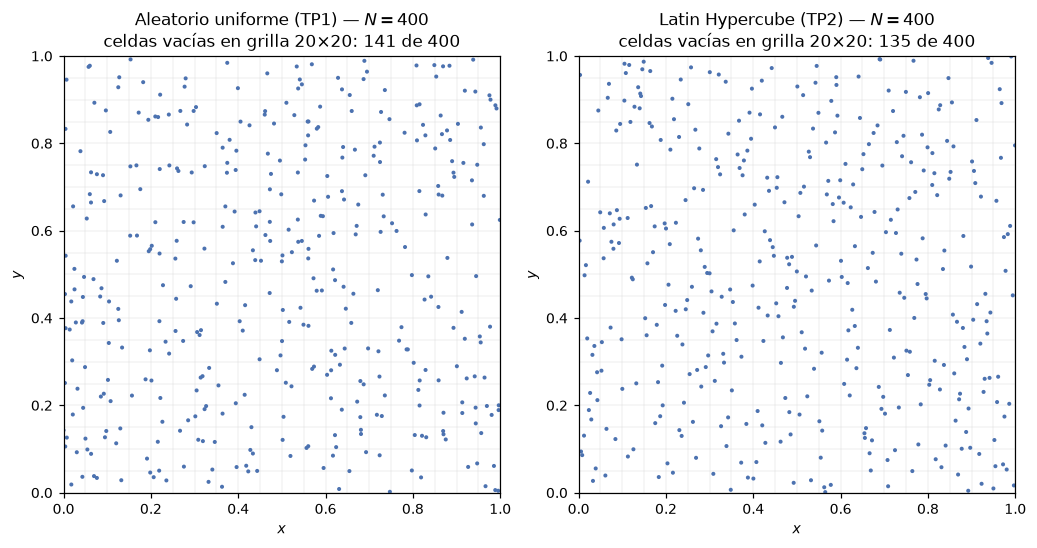

In [9]:
# Comparacion visual: aleatorio uniforme (TP1) vs LHS (TP2)
rng_demo = np.random.default_rng(SEED)
n_demo = 400
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.9))
for ax, (pts, ttl) in zip(axes, [
    (rng_demo.random((n_demo, 2)), f"Aleatorio uniforme (TP1) — $N={n_demo}$"),
    (lhs(n_demo, 2, seed=SEED), f"Latin Hypercube (TP2) — $N={n_demo}$"),
]):
    ax.scatter(pts[:, 0], pts[:, 1], s=7, c="#4C72B0", edgecolors="none")
    for q in np.linspace(0, 1, 21):
        ax.axvline(q, lw=0.3, c="0.85", zorder=0)
        ax.axhline(q, lw=0.3, c="0.85", zorder=0)
    # celdas vacias de una grilla 20x20, como medida burda de cobertura
    H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=20, range=[[0, 1], [0, 1]])
    ax.set(title=f"{ttl}\nceldas vacías en grilla 20×20: {(H == 0).sum()} de 400",
           xlabel="$x$", ylabel="$y$", xlim=(0, 1), ylim=(0, 1), aspect="equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_random_vs_lhs.png", bbox_inches="tight")
plt.show()

### Las seis estrategias no adaptativas, lado a lado

La celda siguiente reproduce el panorama de la Lectura 4.1 sobre el dominio de este problema y lo cuantifica con
dos medidas complementarias:

- **Discrepancia centrada $L_2$** (`qmc.discrepancy`): mide cuánto se aparta la muestra de la uniformidad en
  *todos* los sub-rectángulos del dominio. Es la magnitud que aparece en las cotas de la tabla anterior: menor
  discrepancia implica mejor cuadratura.
- **Celdas vacías** de una grilla $32\times32$ con $N=1024$ puntos (una celda por punto en promedio): una medida
  burda pero directa de "cuánto dominio queda sin ninguna condición de PDE impuesta".

estrategia    discrepancia CD   celdas vacías  (N = 1024, grilla 32×32)
------------------------------------------------
Grid                1.763e-04               0
Random              2.158e-04             363
LHS                 1.283e-05             352
Halton              1.602e-06             241
Hammersley          1.320e-06               0
Sobol               7.676e-07               0


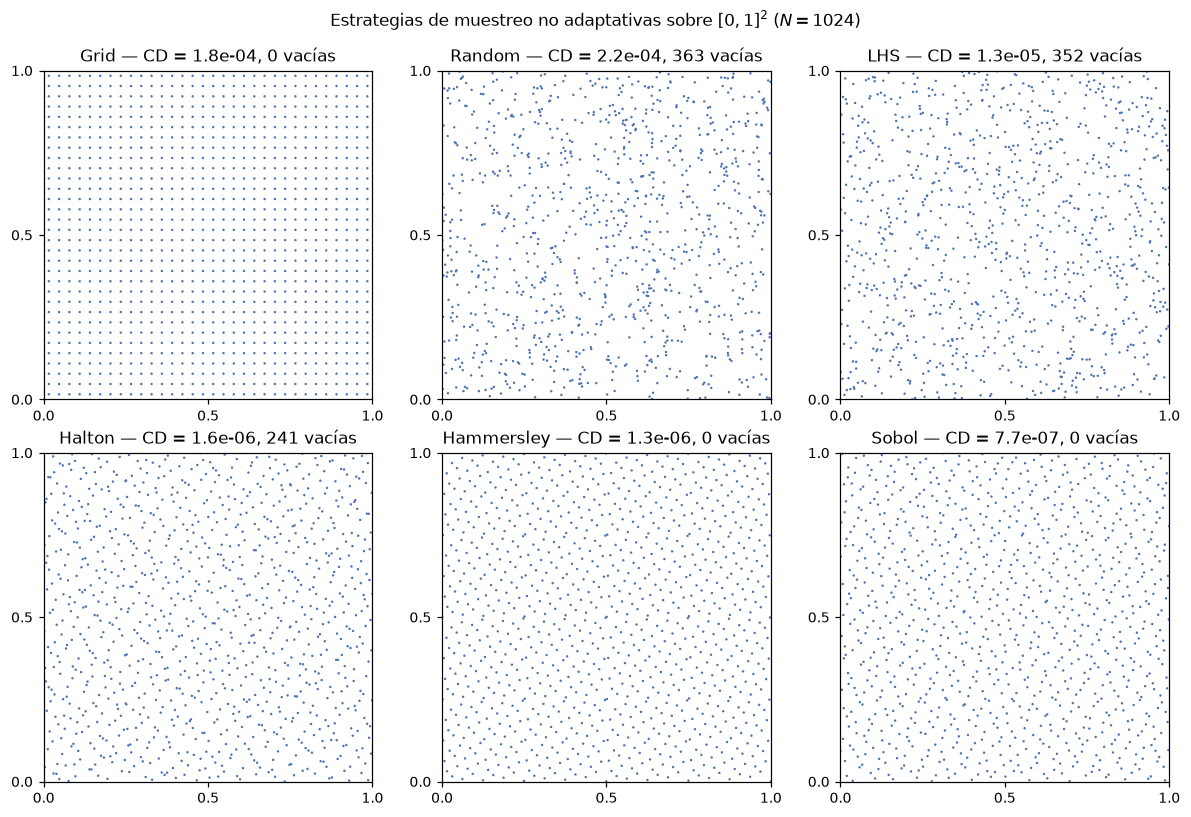

In [10]:
def van_der_corput(n, base):
    """Secuencia de van der Corput (inversa radical) en la base dada."""
    idx = np.arange(1, n + 1, dtype=np.int64)
    out, f = np.zeros(n), 1.0 / base
    while np.any(idx > 0):
        out += f * (idx % base)
        idx = idx // base
        f /= base
    return out


def hammersley(n, d=2):
    """Conjunto de Hammersley: primera coordenada equiespaciada, el resto van der Corput."""
    pts = np.empty((n, d))
    pts[:, 0] = (np.arange(n) + 0.5) / n
    for j, b in enumerate((2, 3, 5, 7)[:d - 1]):
        pts[:, j + 1] = van_der_corput(n, b)
    return pts


def grid_points(n, d=2):
    """Grilla equiespaciada de ~n puntos (centros de celda)."""
    m = int(round(n ** (1 / d)))
    ax = (np.arange(m) + 0.5) / m
    return np.stack(np.meshgrid(*([ax] * d), indexing="ij"), -1).reshape(-1, d)


SAMPLERS = {
    "Grid": lambda n, s: grid_points(n),
    "Random": lambda n, s: np.random.default_rng(s).random((n, 2)),
    "LHS": lambda n, s: lhs(n, 2, seed=s),
    "Halton": lambda n, s: qmc.Halton(2, seed=s).random(n),
    "Hammersley": lambda n, s: hammersley(n),
    "Sobol": lambda n, s: qmc.Sobol(2, seed=s).random(n),
}

N_DEMO, N_BINS = 1024, 32     # 32x32 = 1024 celdas: una por punto, en promedio

fig, axes = plt.subplots(2, 3, figsize=(11, 7.4))
print(f"{'estrategia':<12} {'discrepancia CD':>16} {'celdas vacías':>15}  (N = {N_DEMO}, "
      f"grilla {N_BINS}×{N_BINS})")
print("-" * 48)
for ax, (name, fn) in zip(axes.ravel(), SAMPLERS.items()):
    pts = fn(N_DEMO, SEED)
    disc = qmc.discrepancy(pts, method="CD")
    H, _, _ = np.histogram2d(pts[:, 0], pts[:, 1], bins=N_BINS, range=[[0, 1], [0, 1]])
    empty = int((H == 0).sum())
    print(f"{name:<12} {disc:>16.3e} {empty:>15d}")
    ax.scatter(pts[:, 0], pts[:, 1], s=2.5, c="#4C72B0", edgecolors="none")
    ax.set(title=f"{name} — CD = {disc:.1e}, {empty} vacías", xlim=(0, 1), ylim=(0, 1),
           aspect="equal", xticks=[0, 0.5, 1], yticks=[0, 0.5, 1])
fig.suptitle(f"Estrategias de muestreo no adaptativas sobre $[0,1]^2$ ($N={N_DEMO}$)", y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "01b_estrategias_no_adaptativas.png", bbox_inches="tight")
plt.show()

**Lectura de los números.** La discrepancia ordena las estrategias en el mismo sentido que la tabla de garantías:
Sobol y Hammersley quedan más de dos órdenes de magnitud por debajo de Random, Halton apenas detrás, LHS en el
medio (unas 17 veces mejor que Random) y Grid —pese a su regularidad perfecta— apenas mejor que Random, porque la
discrepancia centrada penaliza el *aliasing* de la grilla. La segunda columna muestra el límite de LHS del que se
habló arriba: **352 celdas vacías contra 363 del muestreo aleatorio**. La estratificación 1D casi no mejora la
cobertura del *plano*; para eso hay que ir a las secuencias de baja discrepancia, que dejan cero celdas vacías
(Sobol, Hammersley) o un tercio menos (Halton).

Con eso queda dimensionado el baseline que fija el enunciado: LHS es una mejora clara sobre el muestreo del TP1
en varianza, pero **no** es el mejor muestreo fijo disponible a igual costo.

---
# 5. Consigna 1 — Baseline LHS

$N_{\rm pde}=10\,000$ y $N_{\rm bc}=1000$ por LHS, $\lambda_{\rm bc}=10$, $\lambda_p=100$, 50 000 épocas, sin
datos rotulados.

In [11]:
torch.manual_seed(SEED)
model_base = PINN(LAYERS).to(DEVICE)
ds_base = build_dataset(lhs(N_PDE_BASE, 2, seed=SEED))
opt_b, sched_b = new_optimizer(model_base)

hist_base, time_base = train(model_base, ds_base, EPOCHS_TOTAL, opt_b, sched_b,
                             tag="Baseline LHS")
print(f"\ntiempo total de entrenamiento: {time_base / 60:.1f} min")


--- Baseline LHS | N_pde = 10,000 | 50,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s


W0805 22:43:11.640000 1791 torch/_inductor/utils.py:1953] [0/1] Not enough SMs to use max_autotune_gemm mode


       0  9.3192e+02  1.1794e+02  1.7306e+00  7.9667e+00  1.00e-03      3.1     nan
    1000  1.9766e-01  4.0541e-02  1.5711e-02  9.6112e-08  1.00e-03     15.4    82.0
    2000  1.4335e-01  2.3331e-02  1.2002e-02  5.1511e-10  1.00e-03     27.2    84.2
    3000  1.1417e-01  1.6942e-02  9.7229e-03  6.5750e-10  1.00e-03     39.1    84.5
    4000  9.3912e-02  1.3165e-02  8.0747e-03  1.3303e-10  1.00e-03     51.4    80.8
    5000  7.5955e-02  9.9007e-03  6.6054e-03  1.5931e-10  1.00e-03     63.7    81.3
    6000  6.2900e-02  7.9598e-03  5.4941e-03  3.3274e-13  1.00e-03     75.9    81.9
    7000  1.4100e-01  7.2693e-02  6.2707e-03  5.5959e-05  1.00e-03     88.2    81.4
    8000  5.1712e-02  7.4520e-03  4.4222e-03  3.8530e-07  1.00e-03    100.5    81.3
    9000  5.8323e-02  1.4208e-02  4.3346e-03  7.6997e-06  1.00e-03    112.9    80.9
   10000  4.9541e-02  1.2212e-02  3.7328e-03  1.7363e-08  5.00e-04    125.2    81.4
   11000  3.8098e-02  5.6896e-03  3.2408e-03  2.1325e-12  5.00e-04    137.5 

In [12]:
metrics_base, metrics_base_in, _ = error_metrics(model_base, ref, "Baseline LHS")


Error sobre todos los nodos (20201) — Baseline LHS

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  9.4454e-01             3.04%   6.6456e-03   3.8583e-01
v                  9.0742e-01             4.31%   6.3844e-03   1.5671e-01
p                  4.3580e+00            29.14%   3.0662e-02   2.9535e+00
p (sin offset)     4.3556e+00            29.43%   3.0645e-02   2.9525e+00

Error sobre excluyendo esquinas, r < 0.05 (20116 nodos) — Baseline LHS

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  7.1029e-01             2.30%   5.0080e-03   1.9176e-02
v                  8.3960e-01             4.00%   5.9197e-03   2.0897e-02
p                  3.5163e-01             4.02%   2.4792e-03   4.2289e-02
p (sin offset)     3.2399e-01             3.84%   2.2844

## Diagnóstico: ¿está balanceada la pérdida que fija el enunciado?

Se aplica el diagnóstico de la sección 3 sobre el baseline, en dos momentos: en la inicialización (misma semilla,
con lo cual es literalmente el modelo de la época 0) y al final de las 50 000 épocas.

In [22]:
torch.manual_seed(SEED)
model_init = PINN(LAYERS).to(DEVICE)          # identico al baseline en la epoca 0

gr_init = grad_report(model_init, ds_base, "baseline, época 0")
gr_final = grad_report(model_base, ds_base, "baseline, época 50 000")


Balance de gradientes — baseline, época 0

término            L_i    ||∇L_i||   λ̂ (Wang)  λ (enunc.)   λ·||∇L_i||
----------------------------------------------------------------------
pde         1.1794e+02  1.2004e+03           1           1   1.2004e+03
bc          1.7306e+00  1.9582e+01        61.3          10   1.9582e+02
anchor      7.9667e+00  8.5842e+01          14         100   8.5842e+03

coseno entre gradientes (negativo = conflicto):
  ∠(pde, bc) = +0.6293
  ∠(pde, anchor) = +0.2238
  ∠(bc, anchor) = -0.0999

Balance de gradientes — baseline, época 50 000

término            L_i    ||∇L_i||   λ̂ (Wang)  λ (enunc.)   λ·||∇L_i||
----------------------------------------------------------------------
pde         6.6704e-04  9.6216e-01           1           1   9.6216e-01
bc          3.5151e-04  2.2489e-02        42.8          10   2.2489e-01
anchor      1.4712e-07  5.8149e-03         165         100   5.8149e-01

coseno entre gradientes (negativo = conflicto):
  ∠(pde, bc) = 

/var/folders/bf/p7_3d4ln30l_vsv0f_41b4sw0000gn/T/ipykernel_1791/3859067688.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  terms[k] = float(t)


**Cómo leerlo.** La columna $\hat\lambda$ es el peso que *igualaría* las magnitudes de los gradientes según la
regla de Wang et al.; la columna siguiente es el peso que efectivamente se usa, fijado por el enunciado. Cuando
$\lambda \ll \hat\lambda$ el término está sub-atendido y la optimización lo va a ignorar; cuando
$\lambda \gg \hat\lambda$, la pérdida está dominada por él y la PDE se optimiza mal. La última columna,
$\lambda\,\|\nabla\mathcal{L}_i\|$, es la contribución real de cada término al paso de Adam: es la magnitud que
hay que comparar entre filas.

Los cosenos miden el tercer modo de falla de la sección 3. Un coseno negativo entre PDE y CB significa que el
paso que baja el residuo empeora las condiciones de borde: el optimizador está en un compromiso, no en un
descenso conjunto, y ninguna elección de $\lambda$ lo resuelve (los $\lambda$ mueven el punto de equilibrio, no
eliminan el conflicto).

Vale subrayar que **este diagnóstico no altera el experimento**: los pesos usados son los del enunciado en las
cuatro configuraciones. Se incluye porque la comparación entre estrategias de muestreo es válida sólo si la
pérdida es la misma en todas, y porque permite saber si el error final está limitado por el muestreo —lo que el
TP mide— o por el balance de la pérdida —lo que el TP mantiene fijo.

---
# 6. Consigna 2 — RAR-D (*Residual-based Adaptive Refinement with Distribution*)

## La idea

Si la pérdida es la integral del residuo estimada por Monte Carlo, el error de esa estimación es proporcional a la
**varianza del integrando**. Repartir los puntos uniformemente cuando el residuo se concentra en unas pocas
regiones es, por lo tanto, ineficiente: la manera de reducir el error sin aumentar $N$ es concentrar las muestras
donde el integrando es grande. Eso es muestreo por importancia, y RAR-D es su instancia en PINNs.

## Las tres estrategias adaptativas y en qué se diferencian

La Lectura 4.1 presenta tres variantes que comparten el esqueleto —muestreo inicial fijo, entrenar, evaluar
residuos, reponer puntos, entrenar, repetir— y difieren en el paso de reposición:

| Estrategia | Cómo elige los puntos nuevos | Qué hace con los viejos |
|---|---|---|
| **RAR-G** (*greedy*) | Toma los $m$ puntos de mayor residuo del pool candidato (sin azar) | Los **acumula**: $T \leftarrow T\cup S$ |
| **RAD** | Re-sortea **todo** el conjunto $T$ según $p(\boldsymbol{x})\propto\varepsilon^k/\mathbb{E}[\varepsilon^k]+c$ | Los **descarta** |
| **RAR-D** | Sortea $m$ puntos según la misma $p(\boldsymbol{x})$ | Los **acumula**: $T \leftarrow T\cup S$ |

Las tres son casos de una misma familia. RAR-G es el límite $k\to\infty$ de RAR-D: con exponente infinito la
densidad colapsa sobre el máximo del residuo y el sorteo se vuelve determinístico. RAD y RAR-D comparten la
densidad y se diferencian sólo en acumular o renovar. **El enunciado pide RAR-D**, es decir: sorteo aleatorio
ponderado (no *greedy*) y conjunto creciente, que es lo que implementa `train_rar_d`.

> **Sobre los valores "por defecto".** El enunciado rotula la configuración A ($k=1$, $c=1$) como "valores por
> defecto de Wu et al.", y es exacto para **RAD**; los valores por defecto que ese trabajo recomienda para
> **RAR-D** son $k=2$, $c=0$ — o sea la configuración **B**. La distinción importa para la expectativa previa:
> B no es una configuración exótica de alto riesgo, es la recomendación del paper para el esquema que efectivamente
> se está implementando, y en los barridos de Wu et al. sobre Burgers es la que mejor rinde. La hipótesis de que
> B pueda fallar acá no viene del paper sino de una particularidad de este problema —la singularidad de las
> esquinas— y es justamente lo que el experimento pone a prueba.

## La métrica y la densidad

Como medida local de violación de la física se toma la norma de los residuos de las tres ecuaciones de gobierno:

$$\varepsilon(\boldsymbol{x}) = \sqrt{r_u(\boldsymbol{x})^2 + r_v(\boldsymbol{x})^2 + r_c(\boldsymbol{x})^2}$$

El anclaje de presión **no participa**: al evaluarse en un único punto fijo no define un campo sobre el dominio.

La densidad de muestreo se define, como es usual, según

$$p(\boldsymbol{x}) \;\propto\; \frac{\varepsilon^k(\boldsymbol{x})}{\mathbb{E}[\varepsilon^k(\boldsymbol{x})]} + c$$

La normalización por la esperanza vuelve al primer término **adimensional y de orden 1**, de modo que $c$ es
directamente comparable con él y su interpretación es estable a lo largo del entrenamiento (a medida que el
residuo baja en promedio, el cociente se mantiene en el mismo rango). Los dos parámetros controlan el compromiso
entre explotar y explorar:

- $k$ **amplifica el contraste**: con $k=2$ una región con el doble de residuo recibe cuatro veces más densidad.
- $c$ **agrega un piso uniforme**: con $c\to\infty$ la densidad tiende a la constante y RAR-D degenera en muestreo
  aleatorio. Con $c=0$ las zonas de residuo bajo tienen probabilidad casi nula de ser muestreadas.

| Configuración | $k$ | $c$ | Característica |
|---|---|---|---|
| **A** — Base (paper) | 1 | 1 | Referencia, valores por defecto de Wu et al. |
| **B** — Alta explotación | 2 | 0 | Sesgo fuerte a zonas de alto residuo |
| **C** — Alta exploración | 1 | 3 | Se aproxima a muestreo aleatorio |

## Advertencia: RAR-D cambia el objetivo que se optimiza

Este es el punto conceptual central de la Lectura 4.1 y conviene dejarlo explícito antes de mirar cualquier
número. Si los puntos se sortean según $p(\boldsymbol{x})$ y la pérdida se calcula como el promedio empírico
habitual,

$$\hat L^{\rm RAD}_N = \frac1N\sum_{i=1}^{N} r(\boldsymbol{x}_i)^2, \qquad \boldsymbol{x}_i\sim p(\boldsymbol{x}),$$

entonces por la ley de los grandes números esa cantidad converge a $\mathbb{E}_p[r^2]$ y **no** a
$L=\mathbb{E}_U[r^2]$. Son integrales distintas: salvo que $p$ sea uniforme, ya no se está minimizando la norma-2
del residuo sobre el dominio. Un estimador insesgado de $L$ requeriría pesar cada punto por $1/p(\boldsymbol{x}_i)$
(muestreo por importancia propiamente dicho); RAR-D **no** lo hace, y eso es deliberado.

| Estrategia | Objetivo efectivamente optimizado | ¿Estima $L$? |
|---|---|---|
| Grid, Random, LHS, Halton, Hammersley, Sobol | $\mathbb{E}_U[r^2] = L$ | Sí — difieren sólo en calidad de cuadratura |
| X-R (resampleo) | $\mathbb{E}_U[r^2] = L$ en cada tramo | Sí — mismo objetivo, menos *staleness* |
| RAD | $\mathbb{E}_p[r^2] \neq L$ | No — cambio deliberado de objetivo |
| RAR-D | $\mathbb{E}_p[r^2] \neq L$, con acumulación de puntos | No — ídem RAD |
| RAR-G | Límite $k\to\infty$ de RAR-D, además dependiente del camino | No — ni siquiera hay una $p$ fija |

Sortear según $p$ sin corregir por $1/p$ es formalmente equivalente a aplicar un **peso por punto**
$w(\boldsymbol{x})\propto p(\boldsymbol{x})$ sobre un muestreo uniforme. Visto así, RAR-D es conceptualmente lo
mismo que **SA-PINN** (Lectura 3.1) —pesos por punto de colocación que atienden preferentemente a las zonas
problemáticas—. No es una analogía suelta: el propio Wu et al. lo demuestra (§2.4), *"if we choose $w(x)$
(divided by a normalizing constant) as the PDF $p(x)$, then the two losses are equal"*. La diferencia está en
cómo se fijan los pesos: en SA-PINN son parámetros **entrenables** que se actualizan por ascenso de gradiente en
un esquema min-max, mientras que en RAR-D quedan **fijados por una heurística** del residuo. RAR-D es más barato (no agrega parámetros ni un segundo optimizador) y más rígido.

Dos consecuencias prácticas, ambas verificables en los resultados:

1. **Las pérdidas no son comparables entre configuraciones.** Cada una evalúa una integral distinta. Esto ya se
   sabía del TP1 por el argumento del estimador de Monte Carlo; acá es peor, porque la diferencia no es de
   varianza sino de objetivo. Sólo el error contra la solución MEF es comparable.
2. **Que RAR-D mejore no está garantizado por la teoría.** Cambiar el objetivo se justifica por una intuición
   —donde el residuo es alto es donde falta trabajo— que no es un teorema. Si el residuo alto está en una región
   que la red no puede representar (las esquinas singulares, ver sección 3), el cambio de objetivo desvía
   esfuerzo hacia una zona irrecuperable y **empeora** el resto del dominio.

## El esquema

1. Inicializar con LHS de **5000** puntos y entrenar **10 000** épocas.
2. Repetir **4 rondas**: evaluar $\varepsilon$ sobre el pool fijo de candidatos $|S_0| = 20\,000$, sortear
   **1000** puntos según $p(\boldsymbol{x})$, agregarlos al conjunto de colocación y entrenar **10 000** épocas.

Total: 50 000 épocas, igual que el baseline.

> **Nota sobre la cantidad final de puntos.** El enunciado indica 5000 iniciales más 4 rondas de 1000 puntos, y
> afirma que "la ronda final llegará a 10 000 puntos de colocación". La suma da **9000**. Se optó por respetar la
> instrucción explícita (4 rondas × 1000 puntos), de modo que las configuraciones RAR-D terminan con 9000 puntos
> contra los 10 000 del baseline. Lo que sí se preserva estrictamente es la **paridad del presupuesto de épocas**
> (50 000 en los cuatro casos), que es lo que domina el costo computacional y lo que hace comparable el
> experimento. La diferencia del 10 % en la cantidad final de puntos juega, si acaso, **en contra** de RAR-D.

Detalles de implementación:

- El **pool de candidatos es el mismo** para las tres configuraciones (misma semilla), de modo que las diferencias
  observadas se deban únicamente a $k$ y $c$ y no al sorteo del pool.
- El sorteo es **sin reemplazo** y excluye los candidatos ya incorporados en rondas anteriores, para que no se
  agreguen puntos duplicados.
- El optimizador y el *scheduler* del learning rate son **continuos** a lo largo de las rondas: no se reinician,
  con lo cual la trayectoria de optimización es equivalente a la del baseline.

In [23]:
def residual_metric(model, xy, batch=5_000):
    """epsilon(x) = sqrt(r_u^2 + r_v^2 + r_c^2) sobre una nube de puntos."""
    out = []
    for i in range(0, len(xy), batch):
        r_x, r_y, r_c = pde_residuals(model, xy[i:i + batch])
        out.append(torch.sqrt(r_x ** 2 + r_y ** 2 + r_c ** 2).detach().flatten())
    return torch.cat(out)


def rar_d_density(eps, k, c):
    """p(x) propto eps^k / E[eps^k] + c, normalizada como distribucion de probabilidad.

    El pasaje a float64 se hace *antes* de normalizar: si se normaliza en float32 la
    suma no da 1 dentro de la tolerancia que exige np.random.Generator.choice.
    """
    w = (eps ** k).cpu().numpy().astype(np.float64)
    p = w / w.mean() + c
    return p / p.sum()


def train_rar_d(k, c, tag, seed=SEED):
    """Entrena una configuracion RAR-D completa y devuelve modelo, historial y diagnosticos."""
    torch.manual_seed(seed)
    model = PINN(LAYERS).to(DEVICE)
    opt, sched = new_optimizer(model)
    rng = np.random.default_rng(seed)

    # Pool de candidatos fijo, comun a todas las configuraciones
    pool = torch.tensor(lhs(POOL_SIZE, 2, seed=seed + 999), dtype=DTYPE, device=DEVICE)
    taken = np.zeros(POOL_SIZE, dtype=bool)

    xy = torch.tensor(lhs(N_PDE_INIT, 2, seed=seed), dtype=DTYPE, device=DEVICE)
    ds = build_dataset(xy.cpu().numpy(), seed=seed)

    hist, t_train, t_select = None, 0.0, 0.0
    rounds = [{"round": 0, "n_pde": len(xy), "added": None}]

    hist, dt = train(model, ds, EPOCHS_PER_ROUND, opt, sched, hist=hist, epoch0=0,
                     tag=f"{tag} — ronda 0 (LHS inicial)")
    t_train += dt

    for r in range(1, N_ROUNDS + 1):
        t0 = time.time()
        avail = np.where(~taken)[0]
        eps = residual_metric(model, pool[avail])
        p = rar_d_density(eps, k, c)
        idx = rng.choice(avail, size=N_ADD, replace=False, p=p)
        taken[idx] = True
        new_pts = pool[idx]
        xy = torch.cat([xy, new_pts])
        ds = build_dataset(xy.cpu().numpy(), seed=seed)
        t_select += time.time() - t0

        rounds.append({"round": r, "n_pde": len(xy), "added": new_pts.cpu().numpy(),
                       "eps_mean": float(eps.mean()), "eps_max": float(eps.max())})

        hist, dt = train(model, ds, EPOCHS_PER_ROUND, opt, sched, hist=hist,
                         epoch0=r * EPOCHS_PER_ROUND, tag=f"{tag} — ronda {r}")
        t_train += dt

    print(f"\n{tag}: entrenamiento {t_train / 60:.1f} min | selección de puntos "
          f"{t_select:.1f} s ({100 * t_select / (t_train + t_select):.1f} % del total)")
    return {"model": model, "hist": hist, "xy": xy.cpu().numpy(), "rounds": rounds,
            "t_train": t_train, "t_select": t_select, "k": k, "c": c, "tag": tag}

In [24]:
run_A = train_rar_d(k=1, c=1, tag="RAR-D A (k=1, c=1)")


--- RAR-D A (k=1, c=1) — ronda 0 (LHS inicial) | N_pde = 5,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
       0  9.3455e+02  1.2057e+02  1.7306e+00  7.9667e+00  1.00e-03      3.2     nan
    1000  1.9746e-01  4.0570e-02  1.5688e-02  1.0784e-07  1.00e-03     10.1   145.0
    2000  1.4197e-01  2.3140e-02  1.1883e-02  6.7096e-10  1.00e-03     16.9   148.2
    3000  1.1299e-01  1.6893e-02  9.6097e-03  3.4614e-10  1.00e-03     23.7   145.9
    4000  9.3195e-02  1.3264e-02  7.9931e-03  6.1212e-11  1.00e-03     30.6   145.2
    5000  8.6218e-02  1.1449e-02  6.5328e-03  9.4406e-05  1.00e-03     37.4   148.3
    6000  6.2111e-02  8.4759e-03  5.3626e-03  9.1178e-08  1.00e-03     44.1   148.0
    7000  5.5242e-02  7.3595e-03  4.7882e-03  4.4533e-10  1.00e-03     51.0   146.0
    8000  5.0982e-02  7.1717e-03  4.3808e-03  2.8499e-08  1.00e-03     57.6   150.3
    9000  8.2283e-02  3.2952e-02  4.9324e-03  7.0328e-08  1.00e-03     64.4 

E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4] failed while attempting to run meta for aten._new_zeros_with_same_feature_meta.default
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4] Traceback (most recent call last):
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_subclasses/fake_tensor.py", line 3086, in _dispatch_impl
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4]     r = func(*args, **kwargs)
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4]         ^^^^^^^^^^^^^^^^^^^^^
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_ops.py", line 875, in __call__
E0805 23:02:35.675000 1791 torch/_subclasses/fake_tensor.py:3090] [0/4]     return self._op(*args, **kwargs)
E0805 23:02:35.67

[aviso] torch.compile falló (TorchRuntimeError), se continúa en modo eager

--- RAR-D A (k=1, c=1) — ronda 2 | N_pde = 7,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
   20000  1.8902e-02  4.7627e-03  1.3456e-03  6.8358e-06  2.50e-04      0.0     nan
   21000  1.4722e-02  1.6347e-03  1.3087e-03  1.0735e-12  2.50e-04     20.8    48.2
   22000  1.3932e-02  1.5141e-03  1.2416e-03  1.7651e-08  2.50e-04     42.3    46.4
   23000  1.3272e-02  1.4942e-03  1.1776e-03  2.3026e-08  2.50e-04     63.7    46.8
   24000  1.2524e-02  1.3722e-03  1.1150e-03  1.5779e-08  2.50e-04     85.2    46.6
   25000  1.2197e-02  1.5222e-03  1.0651e-03  2.4506e-07  2.50e-04    107.0    45.8
   26000  1.1656e-02  1.3762e-03  1.0107e-03  1.7250e-06  2.50e-04    128.2    47.2
   27000  1.1056e-02  1.3003e-03  9.6764e-04  7.8867e-07  2.50e-04    149.4    47.2
   28000  1.1185e-02  1.7487e-03  9.2767e-04  1.5912e-06  2.50e-04    171.3    45.7
   29000  1.005

In [25]:
run_B = train_rar_d(k=2, c=0, tag="RAR-D B (k=2, c=0)")


--- RAR-D B (k=2, c=0) — ronda 0 (LHS inicial) | N_pde = 5,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
       0  9.3455e+02  1.2057e+02  1.7306e+00  7.9667e+00  1.00e-03      0.0     nan
    1000  1.9746e-01  4.0570e-02  1.5688e-02  1.0784e-07  1.00e-03      6.9   144.6
    2000  1.4197e-01  2.3140e-02  1.1883e-02  6.7096e-10  1.00e-03     14.0   142.1
    3000  1.1299e-01  1.6893e-02  9.6097e-03  3.4614e-10  1.00e-03     20.9   144.8
    4000  9.3195e-02  1.3264e-02  7.9931e-03  6.1212e-11  1.00e-03     27.7   146.4
    5000  8.6218e-02  1.1449e-02  6.5328e-03  9.4406e-05  1.00e-03     34.2   153.6
    6000  6.2111e-02  8.4759e-03  5.3626e-03  9.1178e-08  1.00e-03     40.7   154.3
    7000  5.5242e-02  7.3595e-03  4.7882e-03  4.4533e-10  1.00e-03     47.6   144.3
    8000  5.0982e-02  7.1717e-03  4.3808e-03  2.8499e-08  1.00e-03     54.6   144.2
    9000  8.2283e-02  3.2952e-02  4.9324e-03  7.0328e-08  1.00e-03     61.5 

E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5] failed while attempting to run meta for aten._new_zeros_with_same_feature_meta.default
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5] Traceback (most recent call last):
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_subclasses/fake_tensor.py", line 3086, in _dispatch_impl
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5]     r = func(*args, **kwargs)
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5]         ^^^^^^^^^^^^^^^^^^^^^
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_ops.py", line 875, in __call__
E0805 23:17:34.838000 1791 torch/_subclasses/fake_tensor.py:3090] [0/5]     return self._op(*args, **kwargs)
E0805 23:17:34.83

[aviso] torch.compile falló (TorchRuntimeError), se continúa en modo eager

--- RAR-D B (k=2, c=0) — ronda 2 | N_pde = 7,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
   20000  1.9075e-02  3.2366e-03  1.5763e-03  7.4685e-07  2.50e-04      0.0     nan
   21000  1.6836e-02  1.7288e-03  1.5106e-03  1.8629e-08  2.50e-04     21.4    46.8
   22000  1.6074e-02  1.7316e-03  1.4302e-03  4.0589e-07  2.50e-04     42.9    46.6
   23000  1.5254e-02  1.5907e-03  1.3661e-03  2.4372e-08  2.50e-04     64.6    46.0
   24000  1.4720e-02  1.6080e-03  1.3058e-03  5.3542e-07  2.50e-04     85.9    47.0
   25000  1.5173e-02  2.4775e-03  1.2695e-03  3.7538e-09  2.50e-04    106.7    48.0
   26000  1.3482e-02  1.4224e-03  1.2058e-03  2.3548e-08  2.50e-04    127.9    47.2
   27000  1.2961e-02  1.3390e-03  1.1622e-03  1.8329e-09  2.50e-04    149.3    46.8
   28000  1.4186e-02  2.4034e-03  1.1227e-03  5.5554e-06  2.50e-04    170.5    47.0
   29000  1.261

In [26]:
run_C = train_rar_d(k=1, c=3, tag="RAR-D C (k=1, c=3)")


--- RAR-D C (k=1, c=3) — ronda 0 (LHS inicial) | N_pde = 5,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
       0  9.3455e+02  1.2057e+02  1.7306e+00  7.9667e+00  1.00e-03      0.0     nan
    1000  1.9746e-01  4.0570e-02  1.5688e-02  1.0784e-07  1.00e-03      6.7   149.8
    2000  1.4197e-01  2.3140e-02  1.1883e-02  6.7096e-10  1.00e-03     13.2   153.1
    3000  1.1299e-01  1.6893e-02  9.6097e-03  3.4614e-10  1.00e-03     20.0   147.7
    4000  9.3195e-02  1.3264e-02  7.9931e-03  6.1212e-11  1.00e-03     26.8   145.9
    5000  8.6218e-02  1.1449e-02  6.5328e-03  9.4406e-05  1.00e-03     33.6   147.5
    6000  6.2111e-02  8.4759e-03  5.3626e-03  9.1178e-08  1.00e-03     40.4   147.8
    7000  5.5242e-02  7.3595e-03  4.7882e-03  4.4533e-10  1.00e-03     47.2   146.2
    8000  5.0982e-02  7.1717e-03  4.3808e-03  2.8499e-08  1.00e-03     54.1   146.1
    9000  8.2283e-02  3.2952e-02  4.9324e-03  7.0328e-08  1.00e-03     60.9 

E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6] failed while attempting to run meta for aten._new_zeros_with_same_feature_meta.default
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6] Traceback (most recent call last):
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_subclasses/fake_tensor.py", line 3086, in _dispatch_impl
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6]     r = func(*args, **kwargs)
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6]         ^^^^^^^^^^^^^^^^^^^^^
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6]   File "/Users/rodz/Documents/projects/PINN/.venv/lib/python3.11/site-packages/torch/_ops.py", line 875, in __call__
E0805 23:32:28.392000 1791 torch/_subclasses/fake_tensor.py:3090] [0/6]     return self._op(*args, **kwargs)
E0805 23:32:28.39

[aviso] torch.compile falló (TorchRuntimeError), se continúa en modo eager

--- RAR-D C (k=1, c=3) — ronda 2 | N_pde = 7,000 | 10,000 épocas ---
   época       total       L_pde        L_bc    L_anchor        lr     t[s]    it/s
   20000  1.6760e-02  3.6980e-03  1.3059e-03  3.2732e-08  2.50e-04      0.0     nan
   21000  1.4418e-02  1.6223e-03  1.2796e-03  1.2973e-12  2.50e-04     21.1    47.4
   22000  1.3819e-02  1.6327e-03  1.2031e-03  1.5475e-06  2.50e-04     42.2    47.3
   23000  1.3309e-02  1.8220e-03  1.1262e-03  2.2489e-06  2.50e-04     63.5    47.1
   24000  1.2206e-02  1.5173e-03  1.0617e-03  7.1283e-07  2.50e-04     84.6    47.3
   25000  1.2089e-02  1.8124e-03  1.0135e-03  1.4161e-06  2.50e-04    105.9    47.0
   26000  1.1286e-02  1.6648e-03  9.6090e-04  1.2214e-07  2.50e-04    126.9    47.6
   27000  1.0900e-02  1.6932e-03  9.1864e-04  2.0538e-07  2.50e-04    147.8    47.7
   28000  1.0107e-02  1.2947e-03  8.7470e-04  6.5581e-07  2.50e-04    168.8    47.6
   29000  9.768

In [27]:
runs = {}
for r in (run_A, run_B, run_C):
    m, m_in, _ = error_metrics(r["model"], ref, r["tag"])
    r["metrics"], r["metrics_in"] = m, m_in
    runs[r["tag"]] = r


Error sobre todos los nodos (20201) — RAR-D A (k=1, c=1)

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  1.1651e+00             3.75%   8.1977e-03   3.6272e-01
v                  1.1604e+00             5.51%   8.1645e-03   1.6984e-01
p                  5.2019e+00            34.78%   3.6600e-02   3.2361e+00
p (sin offset)     5.1983e+00            35.13%   3.6574e-02   3.2348e+00

Error sobre excluyendo esquinas, r < 0.05 (20116 nodos) — RAR-D A (k=1, c=1)

campo                 ||e||_2   rel. ||e||/||f||         RMSE      |e|_max
--------------------------------------------------------------------------
u                  8.3903e-01             2.72%   5.9157e-03   3.4790e-02
v                  1.0511e+00             5.01%   7.4113e-03   3.2306e-02
p                  4.4942e-01             5.13%   3.1687e-03   5.3373e-02
p (sin offset)     4.1083e-01             4.

---
# 7. Consigna 3 — Discusión

## Norma-2 del error y tiempo total de entrenamiento

In [28]:
rows = [("Baseline LHS", N_PDE_BASE, metrics_base, metrics_base_in, time_base, 0.0,
         hist_base["total"][-1])]
for r in (run_A, run_B, run_C):
    rows.append((r["tag"], len(r["xy"]), r["metrics"], r["metrics_in"],
                 r["t_train"], r["t_select"], r["hist"]["total"][-1]))

print(f"{'configuración':<22} {'N_pde':>7} {'rel u':>8} {'rel v':>8} {'rel p':>8} "
      f"{'rel p*':>8} {'L final':>11} {'t [min]':>9}")
print("-" * 92)
for tag, n, m, m_in, t_tr, t_sel, lfin in rows:
    print(f"{tag:<22} {n:>7,} {m['u']['rel']:>7.2%} {m['v']['rel']:>7.2%} {m['p']['rel']:>7.2%} "
          f"{m_in['p']['rel']:>7.2%} {lfin:>11.3e} {(t_tr + t_sel) / 60:>9.1f}")
print("\n* rel p excluyendo las esquinas singulares")

print(f"\n{'configuración':<22} {'entrenamiento':>15} {'selección':>12} {'overhead':>10}")
print("-" * 62)
for tag, n, m, m_in, t_tr, t_sel, lfin in rows:
    ov = 100 * t_sel / (t_tr + t_sel) if t_sel else 0.0
    print(f"{tag:<22} {t_tr / 60:>14.1f}m {t_sel:>11.1f}s {ov:>9.2f}%")

configuración            N_pde    rel u    rel v    rel p   rel p*     L final   t [min]
--------------------------------------------------------------------------------------------
Baseline LHS            10,000   3.04%   4.31%  29.14%   4.02%   4.193e-03      10.3
RAR-D A (k=1, c=1)       9,000   3.75%   5.51%  34.78%   5.13%   5.829e-03      15.1
RAR-D B (k=2, c=0)       9,000   4.97%   7.69%  37.67%   6.60%   7.023e-03      14.9
RAR-D C (k=1, c=3)       9,000   3.32%   4.66%  33.73%   4.52%   5.238e-03      14.8

* rel p excluyendo las esquinas singulares

configuración            entrenamiento    selección   overhead
--------------------------------------------------------------
Baseline LHS                     10.3m         0.0s      0.00%
RAR-D A (k=1, c=1)               15.1m         0.4s      0.05%
RAR-D B (k=2, c=0)               14.9m         0.2s      0.02%
RAR-D C (k=1, c=3)               14.8m         0.2s      0.03%


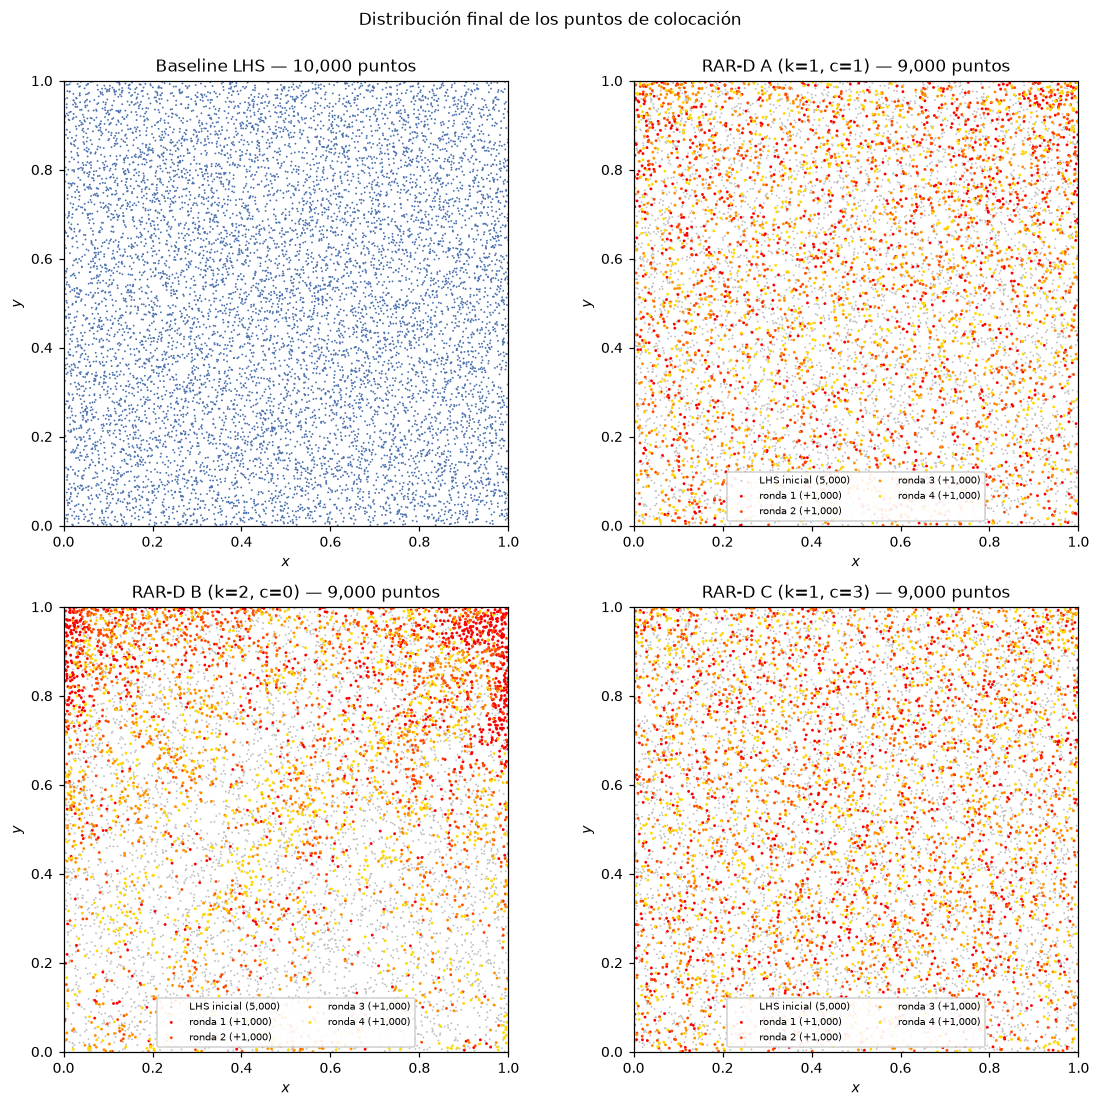

In [29]:
# Distribucion final de los puntos de colocacion en cada configuracion
fig, axes = plt.subplots(2, 2, figsize=(10.5, 10))
axes = axes.ravel()

axes[0].scatter(ds_base["pde"]["xy"].cpu()[:, 0], ds_base["pde"]["xy"].cpu()[:, 1],
                s=1.5, c="#4C72B0", edgecolors="none")
axes[0].set(title=f"Baseline LHS — {N_PDE_BASE:,} puntos", xlabel="$x$", ylabel="$y$",
            xlim=(0, 1), ylim=(0, 1), aspect="equal")

colors = plt.cm.autumn(np.linspace(0, 0.85, N_ROUNDS))
for ax, r in zip(axes[1:], (run_A, run_B, run_C)):
    init = r["xy"][:N_PDE_INIT]
    ax.scatter(init[:, 0], init[:, 1], s=1.5, c="0.75", edgecolors="none",
               label=f"LHS inicial ({N_PDE_INIT:,})")
    for i, rd in enumerate(r["rounds"][1:]):
        ax.scatter(rd["added"][:, 0], rd["added"][:, 1], s=3.5, color=colors[i],
                   edgecolors="none", label=f"ronda {rd['round']} (+{N_ADD:,})")
    ax.set(title=f"{r['tag']} — {len(r['xy']):,} puntos", xlabel="$x$", ylabel="$y$",
           xlim=(0, 1), ylim=(0, 1), aspect="equal")
    ax.legend(loc="lower center", ncol=2, fontsize=6.5, framealpha=0.9)

fig.suptitle("Distribución final de los puntos de colocación", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_distribucion_puntos.png", bbox_inches="tight")
plt.show()

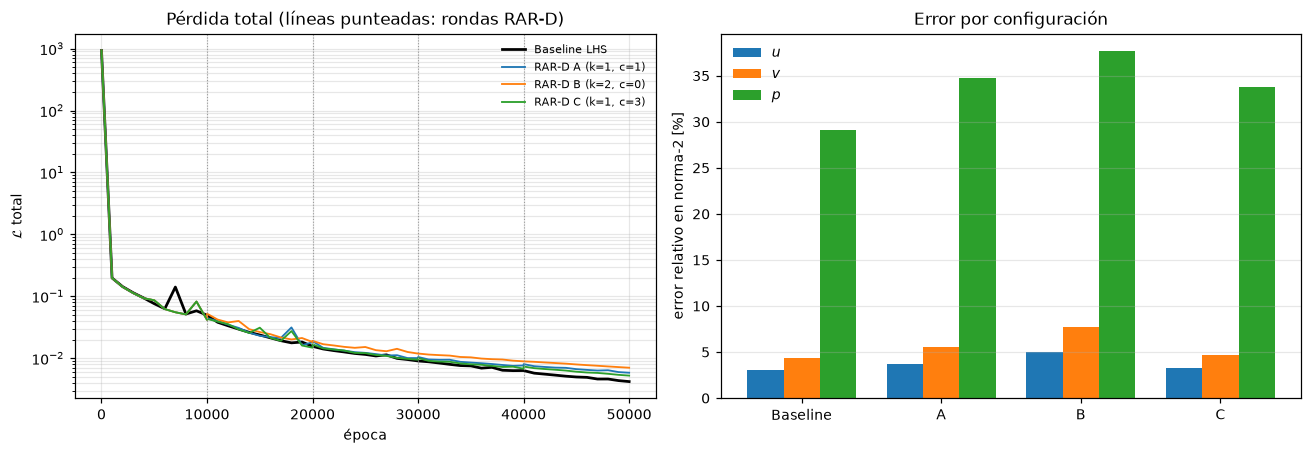

In [30]:
# Evolucion de la perdida y del error
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
ax.semilogy(hist_base["epoch"], hist_base["total"], "k", lw=1.8, label="Baseline LHS")
for r in (run_A, run_B, run_C):
    ax.semilogy(r["hist"]["epoch"], r["hist"]["total"], lw=1.2, label=r["tag"])
for r in range(1, N_ROUNDS + 1):
    ax.axvline(r * EPOCHS_PER_ROUND, lw=0.7, ls=":", c="0.6")
ax.set(xlabel="época", ylabel=r"$\mathcal{L}$ total",
       title="Pérdida total (líneas punteadas: rondas RAR-D)")
ax.legend(frameon=False, fontsize=7.5)
ax.grid(alpha=0.3, which="both")

ax = axes[1]
labels = [t for t, *_ in rows]
xpos = np.arange(len(labels))
for i, f in enumerate(("u", "v", "p")):
    ax.bar(xpos + (i - 1) * 0.26, [m[f]["rel"] * 100 for _, _, m, _, _, _, _ in rows],
           width=0.26, label=f"${f}$")
ax.set(ylabel="error relativo en norma-2 [%]", title="Error por configuración")
ax.set_xticks(xpos)
ax.set_xticklabels(["Baseline", "A", "B", "C"])
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(FIG_DIR / "03_perdidas_y_error.png", bbox_inches="tight")
plt.show()

mejor configuración según el error relativo en u: Baseline LHS


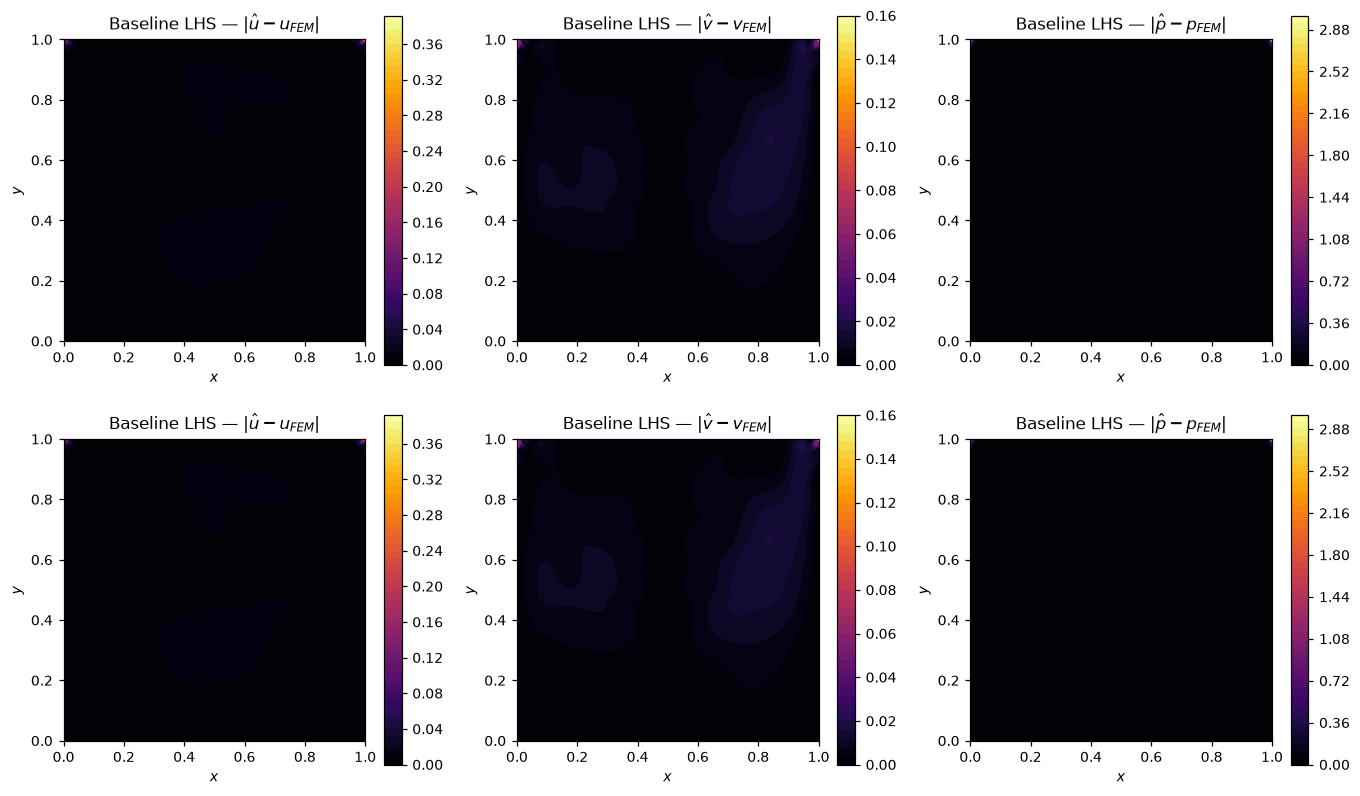

In [31]:
# Campos de error absoluto de la mejor configuracion frente al baseline
best = min(rows, key=lambda r: r[2]["u"]["rel"])
best_model = model_base if best[0] == "Baseline LHS" else runs[best[0]]["model"]
print(f"mejor configuración según el error relativo en u: {best[0]}")

X, Y = np.meshgrid(grid["x"], grid["y"])
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.4))
for row, (mdl, name) in enumerate([(model_base, "Baseline LHS"), (best_model, best[0])]):
    pu, pv, pp = predict(mdl, X.ravel(), Y.ravel())
    for col, (F, k) in enumerate([(pu, "u"), (pv, "v"), (pp, "p")]):
        err = np.abs(F.reshape(X.shape) - grid[k])
        ax = axes[row, col]
        im = ax.contourf(grid["x"], grid["y"], err, levels=50, cmap="inferno")
        fig.colorbar(im, ax=ax)
        ax.set(title=rf"{name} — $|\hat{{{k}}} - {k}_{{FEM}}|$", xlabel="$x$", ylabel="$y$",
               aspect="equal")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_error_absoluto.png", bbox_inches="tight")
plt.show()

In [32]:
summary = {
    "config": {"Re": RE, "layers": LAYERS, "epochs": EPOCHS_TOTAL, "lr": LR,
               "lambda_bc": LAMBDA_BC, "lambda_p": LAMBDA_P, "seed": SEED,
               "device": str(DEVICE), "n_bc": N_BC},
    "rar_d": {"n_init": N_PDE_INIT, "n_rounds": N_ROUNDS, "n_add": N_ADD,
              "pool": POOL_SIZE, "epochs_per_round": EPOCHS_PER_ROUND},
    "balance_gradientes": {"epoca_0": gr_init, "epoca_final": gr_final},
    "resultados": {
        tag: {"n_pde": n, "loss_final": float(lfin),
              "t_train_min": t_tr / 60, "t_select_s": t_sel,
              "errores_relativos": {k: float(v["rel"]) for k, v in m.items()},
              "errores_relativos_sin_esquinas": {k: float(v["rel"]) for k, v in m_in.items()}}
        for tag, n, m, m_in, t_tr, t_sel, lfin in rows},
}
Path("resultados_tp2.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False))
print(json.dumps(summary["resultados"], indent=2, ensure_ascii=False))

{
  "Baseline LHS": {
    "n_pde": 10000,
    "loss_final": 0.004193461965769529,
    "t_train_min": 10.268535649776458,
    "t_select_s": 0.0,
    "errores_relativos": {
      "u": 0.0303672293118741,
      "v": 0.04307380498721801,
      "p": 0.29140403769276424,
      "p (sin offset)": 0.2943246441132945
    },
    "errores_relativos_sin_esquinas": {
      "u": 0.023034424998761432,
      "v": 0.040028229561089736,
      "p": 0.040159011383885314,
      "p (sin offset)": 0.03838112399479788
    }
  },
  "RAR-D A (k=1, c=1)": {
    "n_pde": 9000,
    "loss_final": 0.005828997120261192,
    "t_train_min": 15.096153299013773,
    "t_select_s": 0.44150710105895996,
    "errores_relativos": {
      "u": 0.037459638578271656,
      "v": 0.0550838190079156,
      "p": 0.3478354446510669,
      "p (sin offset)": 0.3512717638650943
    },
    "errores_relativos_sin_esquinas": {
      "u": 0.027209478692910134,
      "v": 0.05011367005867985,
      "p": 0.051327045243931155,
      "p (sin off

## Concentración espacial de los puntos agregados

La figura de distribución muestra cualitativamente dónde fue a parar el refinamiento. La celda siguiente lo
cuantifica: qué fracción de los puntos cae en el entorno de las dos esquinas singulares (los mismos $r<0{,}05$
con los que se construye la tabla de error sin esquinas) y qué fracción cae en la capa límite bajo la tapa
($y>0{,}9$). La referencia es lo que daría un muestreo uniforme: $0{,}39\,\%$ y $10\,\%$ respectivamente.

In [33]:
def zone_fractions(xy):
    """Fraccion de puntos en el entorno de las esquinas singulares y en la capa limite."""
    d0 = np.hypot(xy[:, 0] - 0.0, xy[:, 1] - 1.0)
    d1 = np.hypot(xy[:, 0] - 1.0, xy[:, 1] - 1.0)
    return float(((d0 < CORNER_R) | (d1 < CORNER_R)).mean()), float((xy[:, 1] > 0.9).mean())


unif_corner = 2 * (np.pi * CORNER_R ** 2 / 4)      # dos cuartos de disco de radio CORNER_R
print(f"{'configuración':<22} {'conjunto':<18} {'esquinas':>9} {'y > 0.9':>9}")
print("-" * 62)
print(f"{'uniforme (teórico)':<22} {'—':<18} {unif_corner:>8.2%} {0.10:>9.2%}")
c, l = zone_fractions(ds_base["pde"]["xy"].cpu().numpy())
print(f"{'Baseline LHS':<22} {'10.000 puntos':<18} {c:>8.2%} {l:>9.2%}")
for r in (run_A, run_B, run_C):
    c, l = zone_fractions(r["xy"])
    print(f"{r['tag']:<22} {'9.000 finales':<18} {c:>8.2%} {l:>9.2%}")
    added = np.concatenate([d["added"] for d in r["rounds"] if d["added"] is not None])
    c, l = zone_fractions(added)
    print(f"{'':<22} {'4.000 agregados':<18} {c:>8.2%} {l:>9.2%}")

configuración          conjunto            esquinas   y > 0.9
--------------------------------------------------------------
uniforme (teórico)     —                     0.39%    10.00%
Baseline LHS           10.000 puntos         0.40%    10.00%
RAR-D A (k=1, c=1)     9.000 finales         0.84%    12.56%
                       4.000 agregados       1.55%    15.75%
RAR-D B (k=2, c=0)     9.000 finales         1.08%    16.54%
                       4.000 agregados       2.08%    24.73%
RAR-D C (k=1, c=3)     9.000 finales         0.73%    11.61%
                       4.000 agregados       1.30%    13.63%


## Error dentro de la zona refinada

La celda anterior dice a dónde fueron los puntos; ésta dice si sirvió. Se calcula el error restringido a la capa
límite bajo la tapa ($y>0{,}9$, que es donde RAR-D concentró la mayor parte del refinamiento), **excluyendo** el
entorno de las esquinas singulares para no mezclar las dos cosas. Si el muestreo adaptativo hace lo que promete,
es acá donde tiene que verse.

In [34]:
band = (ref["y"] > 0.9) & away_from_corners(ref)
rel = lambda e, f: np.linalg.norm(e) / np.linalg.norm(f)

print(f"Error relativo en la capa límite (y > 0.9, sin esquinas) — {band.sum()} nodos\n")
print(f"{'configuración':<22} {'rel u':>8} {'rel v':>8} {'rel p':>8}")
print("-" * 48)
for tag, mdl in ([("Baseline LHS", model_base)] +
                 [(r["tag"], r["model"]) for r in (run_A, run_B, run_C)]):
    pu, pv, pp = predict(mdl, ref["x"][band], ref["y"][band])
    ep = pp - ref["p"][band]
    print(f"{tag:<22} {rel(pu - ref['u'][band], ref['u'][band]):>7.2%} "
          f"{rel(pv - ref['v'][band], ref['v'][band]):>7.2%} "
          f"{rel(ep - ep.mean(), ref['p'][band] - ref['p'][band].mean()):>7.2%}")

Error relativo en la capa límite (y > 0.9, sin esquinas) — 1925 nodos

configuración             rel u    rel v    rel p
------------------------------------------------
Baseline LHS             0.64%   3.64%   3.05%
RAR-D A (k=1, c=1)       1.06%   5.04%   3.87%
RAR-D B (k=2, c=0)       1.40%   6.73%   4.90%
RAR-D C (k=1, c=3)       0.93%   4.69%   3.44%


## Discusión

> *¿Cuál de todas las configuraciones alcanzó el mejor desempeño? ¿Es consistente esta conclusión con lo que usted
> esperaba? ¿Por qué sí o por qué no? ¿Cómo impacta la estrategia RAR-D en el costo computacional?*

### Hipótesis previas (redactadas antes de correr el experimento)

Se conservan textuales, porque el valor del contraste depende de que no hayan sido escritas después de ver los
números:

> La cavidad a Re = 100 tiene el residuo fuertemente concentrado: la capa límite bajo la tapa y, sobre todo, las
> dos esquinas superiores, donde la solución exacta no está acotada. Esa geometría del residuo es la que
> determina el comportamiento de cada configuración:
>
> - **C (alta exploración, $c=3$)** debería parecerse al baseline. Con $c=3$ el piso uniforme domina sobre el
>   término de residuo salvo donde $\varepsilon$ supera varias veces su media, de modo que la densidad es casi
>   constante. Es el control del experimento: si C se separara mucho del baseline, la diferencia habría que
>   atribuirla a la cantidad de puntos o al azar, no a la adaptación.
> - **B (alta explotación, $k=2$, $c=0$)** es la configuración de riesgo, y a la vez la que Wu et al. recomiendan
>   por defecto para RAR-D. Al elevar el contraste al cuadrado y eliminar el piso, concentra los puntos donde el
>   residuo es máximo — que en este problema son las esquinas singulares. El peligro tiene nombre en la Lectura
>   3.1: la solución exacta no está acotada ahí, y por *spectral bias* la red no lo va a aprender por más puntos
>   que se le pongan. Sería gastar el presupuesto de refinamiento persiguiendo un residuo irreducible.
> - **A ($k=1$, $c=1$)** equilibra ambos efectos. Es el valor por defecto que Wu et al. dan para RAD y el que la
>   literatura reporta como robusto en general.

Marcador de resultados: **el orden previsto se cumplió** (C ≈ baseline > A > B) y el mecanismo también, pero la
forma del daño no: se anticipó un compromiso —mejor en las esquinas, peor en el interior— y hubo pérdida neta en
todas las regiones, máxima justamente en la zona refinada. La razón de fondo tampoco fue sólo la singularidad;
el experimento agregó una condición más general que no estaba prevista, la saturación del presupuesto de puntos.

### Resultado: ganó el baseline, y el orden es monótono en la agresividad de la adaptación

| Configuración | rel $u$ | rel $v$ | rel $p$ | rel $u$ sin esq. | rel $v$ sin esq. | rel $p$ sin esq. |
|---|---|---|---|---|---|---|
| **Baseline LHS** | **3,04 %** | **4,31 %** | **29,14 %** | 2,30 % | **4,00 %** | **4,02 %** |
| RAR-D C ($k{=}1,c{=}3$) | 3,32 % | 4,66 % | 33,73 % | **2,22 %** | 4,13 % | 4,52 % |
| RAR-D A ($k{=}1,c{=}1$) | 3,75 % | 5,51 % | 34,78 % | 2,72 % | 5,01 % | 5,13 % |
| RAR-D B ($k{=}2,c{=}0$) | 4,97 % | 7,69 % | 37,67 % | 4,05 % | 7,23 % | 6,60 % |

El baseline LHS gana en cinco de las seis métricas; la única excepción es el error en $u$ excluyendo esquinas,
donde C queda 0,08 puntos por debajo. Y el orden no es arbitrario: es exactamente el orden
de cuánto se aparta cada densidad de la uniforme. **C** ($c=3$, casi uniforme) queda pegado al baseline, **A**
($c=1$) claramente peor y **B** ($k=2$, $c=0$, la más agresiva) peor todavía, con un error en $v$ que casi duplica
al del baseline. Cuanta más adaptación, peor resultado.

### El control funcionó: la caída no se explica por el presupuesto de puntos

Las configuraciones RAR-D terminan con 9000 puntos contra 10 000 del baseline, y además entrenan las primeras
10 000 épocas con sólo 5000 (promedio ponderado por época: 7000 contra 10 000). Ese handicap está incorporado en
el diseño del enunciado y hay que descontarlo antes de atribuirle nada a la adaptación. Para eso está **C**, cuya
densidad es casi uniforme: mide el costo del handicap con la adaptación prácticamente desactivada.

Y el resultado es que **el handicap no cuesta casi nada en el grueso del dominio**: C empata o mejora al baseline
en el interior ($0{,}96\times$ en $u$, $1{,}03\times$ en $v$). Con 30 % menos de puntos-época. Por lo tanto, la
degradación de A ($1{,}18$–$1{,}28\times$) y de B ($1{,}64$–$1{,}81\times$) en el interior **no es un artefacto del
presupuesto: es la adaptación misma**.

### Dónde fueron los puntos

La medición de concentración desmiente una versión simplista del mecanismo y precisa la correcta. Fracción de los
4000 puntos agregados por cada configuración que cae en cada zona, y el factor respecto de lo que daría un
muestreo uniforme:

| | esquinas ($r<0{,}05$) | factor | capa límite ($y>0{,}9$) | factor | puntos en esquinas | exceso en $y>0{,}9$ |
|---|---|---|---|---|---|---|
| uniforme | 0,39 % | 1,0× | 10,00 % | 1,0× | 16 | 0 |
| RAR-D C | 1,30 % | 3,3× | 13,63 % | 1,4× | 52 | +145 |
| RAR-D A | 1,55 % | 4,0× | 15,75 % | 1,6× | 62 | +230 |
| RAR-D B | 2,08 % | 5,3× | 24,73 % | 2,5× | 83 | +589 |

(El baseline LHS mide 0,40 % y 10,00 %, indistinguible del valor teórico: buen control de que el muestreador
hace lo que dice.)

Tres lecturas:

1. **La concentración es monótona en la agresividad y reproduce exactamente el orden del error**: C < A < B en
   ambas zonas. El vínculo entre "cuánto se concentró" y "cuánto empeoró" queda establecido por medición, no por
   inferencia.
2. **El destino principal no son las esquinas, es la capa límite.** En términos relativos la sobre-densidad más
   fuerte está en las esquinas (hasta 5,3×), pero en masa absoluta es marginal: B mandó allí 83 de 4000 puntos,
   apenas 67 más que un muestreo uniforme. En cambio mandó 989 a la franja $y>0{,}9$, 589 por encima de lo
   uniforme. La redistribución real es **nueve veces mayor hacia la capa límite que hacia las esquinas**.
3. **El interior perdió entre el 12 % y el 17 % de los puntos.** Contando sobre el conjunto final: el baseline
   tiene 9000 puntos en $y<0{,}9$ y las configuraciones RAR-D 7955 (C), 7870 (A) y 7511 (B).

Esto obliga a descartar la lectura ingenua —"RAR-D vació el presupuesto dentro de la singularidad"— y deja la
correcta, que es más interesante: RAR-D concentró sobre la **franja de alto residuo bajo la tapa**, cuyo extremo
es la singularidad, drenando puntos del 90 % restante del dominio. Nótese además que el drenaje del interior por
sí solo no explica el resultado: C perdió el 11,6 % de los puntos del interior y aun así empató al baseline ahí,
mientras que B perdió el 16,5 % y quedó un 76 % peor. Cinco puntos porcentuales de diferencia en el conteo no
producen esa brecha. Lo que la produce es el cambio de objetivo: no es sólo que haya menos puntos en el interior,
es que la pérdida los pondera menos.

### El refinamiento fue peor justamente donde refinó

La prueba decisiva es el error restringido a la franja que recibió la masa del refinamiento ($y>0{,}9$, sin las
esquinas). Si el muestreo adaptativo hace lo que promete, tiene que verse acá.

| | rel $u$ | rel $v$ | rel $p$ | $u$ vs. base | $v$ vs. base | $p$ vs. base |
|---|---|---|---|---|---|---|
| **Baseline LHS** | **0,64 %** | **3,64 %** | **3,05 %** | 1,00 | 1,00 | 1,00 |
| RAR-D C | 0,93 % | 4,69 % | 3,44 % | 1,45 | 1,29 | 1,13 |
| RAR-D A | 1,06 % | 5,04 % | 3,87 % | 1,66 | 1,38 | 1,27 |
| RAR-D B | 1,40 % | 6,73 % | 4,90 % | **2,19** | **1,85** | **1,61** |

(Los niveles absolutos no son comparables con los de las otras tablas: en esta franja $u\approx1$, de modo que el
denominador $\|u\|$ es grande y todos los errores relativos bajan. Lo que importa es la comparación entre
configuraciones, que comparten denominador.)

El resultado es inequívoco: **el baseline gana en la franja refinada por márgenes mayores que en cualquier otra
región**. Poniendo las tres descomposiciones una al lado de la otra (factor de degradación respecto del baseline):

| | $u$ en $y>0{,}9$ | $u$ en el interior | $u$ en las esquinas |
|---|---|---|---|
| RAR-D C | 1,45 | **0,96** | 1,24 |
| RAR-D A | 1,66 | 1,18 | 1,30 |
| RAR-D B | **2,19** | 1,76 | 1,47 |

El caso de C es el más elocuente: con la adaptación casi desactivada **empata al baseline en el interior y aun así
pierde un 45 % en la franja que favoreció**. No hay ninguna región en la que ninguna configuración de RAR-D le
gane al baseline. La hipótesis del compromiso queda descartada de forma completa: no hubo trueque, hubo pérdida
en todas partes, y la mayor pérdida ocurrió exactamente donde se concentró el esfuerzo.

### Por qué agregar puntos empeoró la zona a la que se agregaron

El resultado parece paradójico y no lo es. Se explica por dos hechos que el propio experimento mide:

**1. El presupuesto de puntos ya estaba saturado.** La configuración C alcanza el error del baseline en el
interior con un 30 % menos de puntos-época. Si 7000 puntos rinden lo mismo que 10 000, entonces la calidad de la
cuadratura **no era el factor limitante**: en un dominio 2D, algunos miles de puntos ya estiman la integral del
residuo con error despreciable frente a las demás fuentes de error. El valor marginal de un punto de colocación
adicional era prácticamente nulo, en cualquier lugar donde se lo pusiera.

**2. Lo único que quedaba por cambiar era el objetivo, y ese cambio sólo podía restar.** Es exactamente la
distinción de la Lectura 4.1: las estrategias no adaptativas difieren únicamente en la calidad de la cuadratura
—que acá ya estaba saturada, con lo cual no había nada que ganar— mientras que RAD y RAR-D **cambian la integral
que se minimiza**, de $\mathbb{E}_U[r^2]$ a $\mathbb{E}_p[r^2]$. Con la cuadratura saturada, el único efecto neto
de RAR-D es ese cambio de objetivo.

Y una PINN no es un solver local: es **una sola red** que representa el campo en todo el dominio. Los puntos de
colocación no "resuelven" su vecindario, ponderan el objetivo global. Sobre-ponderar la franja bajo la tapa no
compra precisión ahí —donde no faltaban puntos— pero sí deteriora la solución en el 90 % restante del dominio, y
como la red es única, ese deterioro vuelve sobre la franja. De ahí que la degradación sea máxima justamente en la
zona más favorecida por el muestreo.

### Dónde se rompió: el refinamiento empeoró también las esquinas

Descomponiendo la norma-2 entre los 85 nodos del entorno de las esquinas ($r<0{,}05$) y los 20 116 restantes
—$\|e\|^2_{\rm total} = \|e\|^2_{\rm esquinas} + \|e\|^2_{\rm interior}$— se puede ver exactamente qué compró cada
configuración. Valores relativos al baseline ($>1$ es peor):

| | $u$ esq. | $v$ esq. | $p$ esq. | $u$ int. | $v$ int. | $p$ int. |
|---|---|---|---|---|---|---|
| RAR-D C | 1,24 | 1,34 | 1,16 | **0,96** | 1,03 | 1,13 |
| RAR-D A | 1,30 | 1,43 | 1,19 | 1,18 | 1,25 | 1,28 |
| RAR-D B | 1,47 | 1,65 | 1,29 | 1,76 | 1,81 | 1,64 |

Esto **refuta la hipótesis del compromiso**. La expectativa previa era que RAR-D mejorara las esquinas a costa
del interior; lo que ocurrió es que empeoró **las dos**. Ninguna configuración le ganó al baseline en la región
donde concentró los puntos. Comparando A y B contra C —o sea, aislando el efecto de la adaptación del efecto del
presupuesto— el refinamiento cuesta entre 15 % y 25 % (A) y entre 45 % y 85 % (B) en el interior, y además entre
3 % y 7 % (A) y entre 10 % y 25 % (B) **en las propias esquinas**.

El único indicador que sí mejoró es el error **máximo puntual**: $|e_u|_{\max}$ pasa de $0{,}386$ en el baseline a
$0{,}363$–$0{,}369$ en las tres configuraciones RAR-D, una mejora del 5 % justo en el nodo de la singularidad. Ese
es todo el beneficio obtenido, y se pagó con entre 20 % y 80 % de degradación en el resto del dominio. La lectura
es que el refinamiento afila el ajuste exactamente sobre el punto singular y deteriora su vecindario.

### Por qué: era predecible, y estaba anticipado

El mecanismo es el de la sección 3. La solución exacta de la cavidad **no está acotada en las dos esquinas
superiores**: la tapa impone $u=1$ y las paredes $u=0$, y la discontinuidad genera contenido espectral
arbitrariamente alto. Por *spectral bias*, una red suave con activación $\tanh$ no puede representar eso: el
residuo ahí es **irreducible**, no un síntoma de falta de puntos.

RAR-D no tiene forma de distinguir "residuo alto porque faltan puntos" de "residuo alto porque la solución no es
representable". Su heurística —muestrear donde $\varepsilon$ es grande— asume implícitamente lo primero. En este
problema vale lo segundo, y entonces la estrategia hace exactamente lo contrario de lo que conviene: mueve
presupuesto hacia la única región donde no puede servir para nada.

La magnitud del desbalance se ve en un solo número: **las 85 nodos de esquina, que son el 0,42 % del dominio
evaluado, concentran el 99,3 % del error cuadrático en la presión** y el 43 % del de $u$. El campo de residuos que
RAR-D usa como guía está dominado por esa región. Es lo mismo que dice la Lectura 4.1 en abstracto —RAD y RAR-D
optimizan $\mathbb{E}_p[r^2]\neq L$, un objetivo distinto— hecho concreto: acá la $p(\boldsymbol{x})$ inducida
concentra el objetivo sobre una zona de medida casi nula e irrecuperable.

**¿Es consistente con lo esperado?** Parcialmente, y la parte que falló es informativa. La hipótesis
pre-registrada de la sección 7 —que B era la de riesgo por la singularidad, y que C sería un control cercano al
baseline— se confirmó en el orden y en el mecanismo. Lo que **no** se cumplió es la forma del daño: se esperaba un
compromiso (mejor en las esquinas, peor en el interior) y lo que hubo fue una pérdida neta en ambos lados. La
expectativa de la literatura tampoco se cumplió: Wu et al. reportan que RAD y RAR-D dominan a los muestreos fijos
en difusión, Burgers, Allen-Cahn y ondas, y que $k=2$, $c=0$ (la configuración B) es el valor por defecto
recomendado **para RAR-D**. Acá B fue la peor de las cuatro. La diferencia entre aquellos casos y éste es que sus
soluciones son suaves: el residuo alto marca zonas efectivamente recuperables. **La conclusión no es que RAR-D no
sirva, sino que su supuesto no se cumple en problemas con singularidades geométricas**, y la cavidad con tapa
deslizante es el caso de libro.

### Costo computacional: hay que separar el algoritmo de la implementación

La tabla de tiempos muestra las configuraciones RAR-D un 45 % **más lentas** que el baseline (14,8–15,1 min contra
10,3 min) pese a entrenar con menos puntos. Eso es contraintuitivo y, efectivamente, no es atribuible a RAR-D.

Lo primero que hay que descartar es el sobrecosto del algoritmo: evaluar $\varepsilon$ sobre el pool de 20 000
candidatos cuatro veces y sortear la densidad costó **entre 0,2 y 0,4 segundos en total**, un $0{,}05\,\%$ del
tiempo de entrenamiento. Es despreciable, y era esperable: son cuatro pasadas *forward* sin gradientes contra
50 000 pasos de optimización.

El origen real está en el log de `it/s`, desagregado por ronda:

| Ronda | $N_{\rm pde}$ | it/s medidas | modo |
|---|---|---|---|
| 0 | 5000 | 147 | compilado |
| 1 | 6000 | 125 | compilado |
| 2 | 7000 | **47** | *eager* |
| 3 | 8000 | **40** | *eager* |
| 4 | 9000 | **35** | *eager* |

En las tres corridas RAR-D, y siempre en la ronda 2, aparece el aviso
`[aviso] torch.compile falló (TorchRuntimeError), se continúa en modo eager`. Al tercer cambio de forma del tensor
de puntos, la compilación falla y el modelo cae —de manera permanente, por diseño del *fallback*— a modo *eager*
para las 30 000 épocas restantes. Un banco de pruebas aislado confirma que las cifras corresponden exactamente a
ese modo: en *eager* se miden 50,7 / 43,7 / 37,7 it/s para $N=7000/8000/9000$, contra 111,6 / 108,7 / 95,7
compilado. El baseline, con una única forma de tensor, nunca recompiló y corrió compilado de punta a punta.

Descontando el artefacto, con los mismos regímenes compilados que exhibieron las rondas 0 y 1, las cuatro rondas
de RAR-D habrían tomado **≈ 7,9 min contra los 10,3 min del baseline: un 23 % más barato**, coherente con entrenar
con un 30 % menos de puntos-época. La respuesta correcta a la pregunta del enunciado es entonces:

> **RAR-D es intrínsecamente más barato que el baseline en este esquema** —el sobrecosto de selección es del orden
> del 0,05 % y se compensa con creces por entrenar la mayor parte del tiempo con menos puntos—, pero es
> **frágil frente a las optimizaciones de compilación**, porque cambia la forma de los tensores en cada ronda. En
> esta corrida esa fragilidad costó 7 minutos por configuración, tres veces más que todo el sobrecosto algorítmico
> junto.

El arreglo es directo y quedó verificado en el banco de pruebas: compilar con `dynamic=False` mantiene el
rendimiento en las seis formas medidas (167 → 89 it/s de 5000 a 10 000 puntos). Alternativamente, sobredimensionar
el tensor de colocación al tamaño final y enmascarar, para que la forma no cambie nunca.

### Qué dice el diagnóstico de gradientes

| | $\|\nabla\mathcal{L}_{\rm pde}\|$ | $\|\nabla\mathcal{L}_{\rm bc}\|$ | $\|\nabla\mathcal{L}_{\rm anchor}\|$ | $\hat\lambda_{\rm bc}$ | $\hat\lambda_p$ | $\cos(\nabla_{\rm pde},\nabla_{\rm bc})$ |
|---|---|---|---|---|---|---|
| Época 0 | 1200 | 19,6 | 85,8 | 61,3 | 14,0 | +0,63 |
| Época 50 000 | 0,962 | 0,0225 | 0,00581 | 42,8 | 165 | +0,58 |

Tres conclusiones, todas relevantes para interpretar el resultado principal:

1. **No hay conflicto de direcciones.** Los cosenos son positivos y grandes en los dos extremos del entrenamiento
   ($+0{,}63$ y $+0{,}58$ entre PDE y CB). El tercer modo de falla de la Lectura 3.1 simplemente no está presente
   en este problema: los términos cooperan. El único coseno negativo es CB–anclaje en la época 0 ($-0{,}10$), y se
   desvanece a $+0{,}002$ al final.
2. **$\lambda_p=100$ está mal calibrado al inicio, pero es inofensivo.** En la época 0 la contribución del anclaje
   al gradiente es $100\times85{,}8 = 8584$, **siete veces** la del término de PDE: la optimización arranca
   dominada por un único punto. La regla de Wang habría pedido $\hat\lambda_p=14$. No hace daño porque
   $\mathcal{L}_{\rm anchor}$ se desploma a $\sim10^{-7}$ antes de la época 1000 y deja de participar; después de
   ese transitorio el peso correcto sería 165 y el usado es 100, o sea razonable.
3. **$\lambda_{\rm bc}=10$ sub-pondera el borde en un factor 4** de forma sostenida ($\hat\lambda_{\rm bc}=42{,}8$
   al final). Es la única corrección con fundamento cuantitativo que sugiere el diagnóstico, y queda anotada como
   trabajo futuro: el enunciado fija $\lambda_{\rm bc}=10$ y cambiarlo invalidaría la comparación.

En conjunto: al final del entrenamiento las contribuciones ponderadas son $0{,}96$ / $0{,}22$ / $0{,}58$ para
PDE / CB / anclaje, dentro del mismo orden de magnitud. **La pérdida no está desbalanceada de forma patológica**,
lo cual refuerza el diagnóstico del resultado principal: el techo de precisión no está en los pesos ni en el
muestreo, está en la representabilidad de la singularidad.

### Sobre la comparabilidad de las pérdidas

El TP1 concluyó que la pérdida no es un indicador confiable de calidad, y acá el argumento es más fuerte todavía:
las tres configuraciones RAR-D evalúan $\mathbb{E}_p[r^2]$, una integral distinta de la que evalúa el baseline.
Con todo, hay una componente que **sí** es directamente comparable: $\mathcal{L}_{\rm bc}$ se calcula sobre los
**mismos 1000 puntos de borde** en las cuatro configuraciones, sin sesgo alguno. Sus valores finales son

| Baseline | C | A | B |
|---|---|---|---|
| $3{,}51\times10^{-4}$ | $4{,}49\times10^{-4}$ | $5{,}03\times10^{-4}$ | $6{,}13\times10^{-4}$ |

y ordenan las configuraciones **exactamente igual que el error contra la solución MEF**. Es una confirmación
independiente del ranking que no usa el *ground-truth*: el muestreo del interior degradó incluso la capacidad de
satisfacer las condiciones de borde. La pérdida total ordena igual, pero eso no la valida como métrica: el sesgo
de muestreo la infla en la misma dirección en que empeora la solución, y los dos efectos son indistinguibles.

### Comparación contra el TP1

El eje que cierra el recorrido: cuánto de la mejora respecto del TP1 viene del muestreo y cuánto del presupuesto.

| Modelo | $N_{\rm pde}$ | $N_{\rm bc}$ | épocas | muestreo | rel $u$ | rel $v$ | rel $p$ sin esq. |
|---|---|---|---|---|---|---|---|
| TP1 — base | 1000 | 100 | 20 000 | aleatorio | 21,07 % | 36,15 % | 36,62 % |
| TP1 — denso | 5000 | 400 | 20 000 | aleatorio | 8,79 % | 14,95 % | 14,30 % |
| **TP2 — baseline** | 10 000 | 1000 | 50 000 | **LHS** | **3,04 %** | **4,31 %** | **4,02 %** |

El salto es de un factor 7 en $u$ y 8 en $v$ respecto del modelo base del TP1. Ahora bien, **no es atribuible al
muestreo**: entre el modelo base y el denso del TP1, con la misma estrategia aleatoria y las mismas épocas,
multiplicar los puntos por cinco ya mejoró $u$ en un factor 2,4. El baseline del TP2 duplica otra vez los puntos,
multiplica por 2,5 las épocas, sube $\lambda_p$ de 1 a 100 y encima cambia a LHS: cuatro cambios simultáneos, de
los cuales el muestreo es sólo uno y —a la luz de lo medido acá, donde 7000 puntos rinden igual que 10 000— casi
seguramente el menos importante. La contribución específica de LHS sobre aleatorio no se puede aislar con estas
corridas; haría falta un baseline TP2 con muestreo aleatorio, idéntico en todo lo demás.

Lo que sí queda establecido es la escala del problema: **el error en $p$ excluyendo esquinas bajó de 36,6 % a
4,0 %**, y el residuo de error que queda está dominado por la singularidad, no por el grueso del dominio.

### Revisión frente a Wu et al. (arXiv:2207.10289)

El enunciado pide considerar el trabajo del que sale RAR-D. Contrastar los resultados contra el paper original
—y no sólo contra el resumen de la Lectura 4.1— cambia tres cosas de la lectura anterior.

**1. El paper documenta la saturación que acá se observó, y su tabla principal la evita deliberadamente.**
La Tabla 2 del paper, que es la que se reprodujo en la sección 4, viene con esta advertencia en el texto:
*"A relatively small number of residual points is chosen to show the difference among different methods"*
(§3.1). Los $N$ de esa tabla —30 en difusión, 2000 en Burgers, 1000 en Allen-Cahn, 2000 en ondas— están elegidos
para que las diferencias sean visibles. Cuando el presupuesto crece, el propio paper reporta que las diferencias
desaparecen:

- Difusión: *"When the number of points is large (e.g., more than 70), all these methods have similar
  performance"* (§3.2).
- Difusión con 30 puntos: *"Compared with Random-R (0.12 %), RAD and RAR-D (0.11 %) are not significantly better.
  The reason could be that the solution of this diffusion equation is very smooth, so uniformly distributed points
  are good enough"* (§3.2).
- Allen-Cahn: *"As the number of residual points becomes significantly large, the difference between these uniform
  sampling methods becomes negligible"* (§3.4).
- Ondas, sobre Random-R: *"if the number of residual points is large, the predictions by the Random method are
  already highly accurate, so the Random-R is unable to further improve the accuracy"* (§3.5).

Este TP corre con **10 000 puntos en un dominio 2D**, cinco veces la densidad del caso Burgers del paper (que es
también 2D, con 2000 puntos) y por encima del rango donde ellos muestran saturación. La hipótesis de saturación
de la sección anterior deja de ser una racionalización a posteriori: es el régimen que el paper mismo identifica
como aquel en el que el muestreo deja de importar.

**2. El resultado no contradice al paper: reproduce el modo de falla que el paper reporta para las variantes
acumulativas.** La afirmación de que RAD y RAR-D dominan vale para los cuatro problemas *directos*. En los dos
problemas *inversos* ocurre exactamente lo que acá se midió — textual del paper (§3.6, difusión-reacción):
*"However, RAR-G and RAR-D are even worse than the Random sampling"*. Los números de su Tabla 3 lo confirman:

| Difusión-reacción (inverso), 15 puntos | $u(x)$ | $k(x)$ |
|---|---|---|
| Random | 0,35 % | 5,77 % |
| RAD ($k{=}1,c{=}1$) | **0,17 %** | **2,76 %** |
| RAR-G | 1,12 % | 15,9 % |
| **RAR-D ($k{=}2,c{=}0$)** | **0,76 %** | **10,3 %** |

El patrón es nítido: **RAD, que resortea todo el conjunto, es robusto; RAR-G y RAR-D, que acumulan, son las
frágiles**. Tiene sentido mecánicamente: RAD renueva la distribución en cada ronda y puede corregir un sesgo mal
puesto, mientras que RAR-D lo fija de manera permanente en el conjunto. El enunciado pide justamente RAR-D, la
variante acumulativa, y la jerarquía del paper es explícita al respecto: *"RAD with $k=1$ and $c=1$ can be chosen
as the default sampling method when solving a new PDE"*, y RAR-D se recomienda sólo como alternativa más barata
*"for the case with limited computational resources"* (§4).

**3. La granularidad del refinamiento de este TP está lejos de la que el paper valida, y ellos muestran que
importa.** En el paper, RAR-D agrega **10 puntos cada 2000 iteraciones** (Burgers: de 1000 a 2000 puntos en 100
rondas). Además hacen la ablación explícita sobre cuántos puntos agregar por vez (Figs. 6G–I, ecuación de ondas),
probando 5, 10, 25, 50 y 100, y concluyen: *"we find that the best strategy is to add 10 points each time"*, con
las curvas de 50 y 100 claramente peores.

| | puntos agregados por ronda | rondas |
|---|---|---|
| Wu et al. (recomendado) | 10 | ~100 |
| Wu et al. (peor caso probado) | 100 | ~25 |
| **Este TP (por enunciado)** | **1000** | **4** |

El esquema del enunciado agrega **cien veces más puntos por ronda que el óptimo del paper y diez veces más que el
peor caso que ellos probaron**. Es una desviación de primer orden: con 4 rondas, la red ve sólo cuatro
actualizaciones de la distribución, y cada una desplaza el 11 % del conjunto de golpe, basándose en un campo de
residuos que queda inmediatamente desactualizado. **Parte de la degradación medida acá puede deberse a esto y no
a la singularidad**, y el experimento no permite separar ambos efectos. Es la limitación más importante de este
TP frente al método que dice estar evaluando.

**4. Una diferencia estructural que no se puede pasar por alto: el paper impone las condiciones de borde de
manera *hard*.** Textual (§2.1): *"In this study, the boundary conditions are enforced exactly and automatically.
Hence, for a forward problem, the loss function is $\mathcal{L}(\theta;\mathcal{T}) =
\mathcal{L}_f(\theta;\mathcal{T}_f)$"*. En su montaje, **el muestreo determina el 100 % del objetivo**. Acá la
pérdida es $\mathcal{L}_{\rm pde} + 10\,\mathcal{L}_{\rm bc} + 100\,\mathcal{L}_{\rm anchor}$: el muestreo
controla un término de tres, y el sesgo adaptativo del interior compite contra dos términos evaluados sobre
conjuntos **fijos y uniformes**. El objetivo resultante es una mezcla de una integral sesgada en el interior y
dos insesgadas en el borde, que el paper nunca prueba. La observación de la sección anterior —que
$\mathcal{L}_{\rm bc}$ empeora monótonamente con la agresividad del muestreo— es un efecto de esa mezcla y no
tiene contraparte en el paper.

**Correspondencia del resto del protocolo.** Lo que sí coincide: la métrica $\varepsilon$ y la PDF
$\varepsilon^k/\mathbb{E}[\varepsilon^k]+c$ (Ec. 2 del paper), los valores por defecto $k{=}1,c{=}1$ para RAD y
$k{=}2,c{=}0$ para RAR-D (§2.3.2 y §2.3.3), el muestreo por fuerza bruta desde un conjunto denso de candidatos
(§2.3.2), y la fracción inicial: el paper pre-entrena con el 50 % del total final y el enunciado con 5000/9000 =
56 %. Difieren, además de lo ya dicho: el pool de candidatos, que el paper vuelve a sortear en cada ronda
mientras que acá es fijo y con exclusión de los ya tomados —lo cual **agota progresivamente la zona de residuo
alto** y vuelve al refinamiento menos agresivo en las últimas rondas—, y el optimizador, que en el paper es
Adam + L-BFGS para Burgers, Allen-Cahn y ondas, mientras que acá es Adam solo.

### Limitaciones de este experimento

1. **Una sola semilla por configuración.** No hay estimación de la variabilidad corrida a corrida. Wu et al.
   corren **cada caso al menos 10 veces** y reportan media geométrica y desviación estándar precisamente por eso
   (§3); sus desviaciones son comparables a las diferencias que acá se miden (p. ej. $13{,}3\pm8{,}35$ % para
   Random en Burgers, $22{,}2\pm16{,}9$ % en Allen-Cahn). Las cuatro configuraciones
   comparten inicialización, puntos de borde y pool de candidatos, lo cual es un diseño pareado que reduce el
   ruido, pero no lo elimina. **La brecha baseline–C (9 % relativo) está dentro de lo que podría ser ruido; la
   brecha baseline–B (63 % en $u$, 78 % en $v$) es demasiado grande para serlo.** Las conclusiones sobre B, y la
   monotonía del orden, son robustas; la afirmación "el baseline le gana a C" no lo es.
2. **Arquitectura no re-optimizada.** 5×64 viene del barrido del TP1, hecho con 1000 puntos y 20 000 épocas. En
   este régimen —diez veces más puntos, 2,5 veces más épocas— podría no estar en el codo de la curva.
3. **9000 contra 10 000 puntos**, por la inconsistencia aritmética del enunciado. Mitigado por el control C, que
   acota el efecto a prácticamente cero en el interior.
4. **El tiempo medido de RAR-D no es el tiempo del algoritmo**, por el *fallback* a *eager* documentado arriba.
   Las cifras corregidas son estimaciones basadas en las tasas compiladas medidas, no mediciones directas: la
   verificación limpia sería volver a correr una configuración con `dynamic=False`.

### Conclusión

**El baseline LHS fue la mejor de las cuatro configuraciones**, y las tres variantes de RAR-D lo empeoraron de
forma monótona con la agresividad de la densidad de muestreo. La razón no es que el muestreo adaptativo sea malo,
sino que su premisa —residuo alto = zona que falta resolver— es falsa en un problema cuya solución exacta es
singular: el residuo en las esquinas de la cavidad es irreducible para una red suave, y todo punto que RAR-D
manda ahí es presupuesto restado del resto del dominio sin contrapartida. El experimento lo muestra de la manera
más nítida posible: **la mayor degradación ocurrió exactamente en la región que el refinamiento favoreció** — la
capa límite bajo la tapa, donde el error en $u$ empeora hasta 2,19× contra 1,76× en el interior y 1,47× en las
esquinas.

Es, en ese sentido, un resultado más útil que una confirmación: dice que la elección de estrategia de muestreo no
es independiente de la regularidad de la solución buscada, y que el diagnóstico previo —dónde está el error y si
es representable— tiene que preceder a la elección del método. Para esta cavidad, las palancas con fundamento
quedaron identificadas y son otras: atacar el *spectral bias* con *Fourier embeddings*, subir $\lambda_{\rm bc}$
al orden de 40 que indica la regla de Wang, o directamente cambiar el baseline no adaptativo a Hammersley o
Sobol, dos órdenes de magnitud mejores en discrepancia que LHS al mismo costo.

---

## Cierre — respuestas a la consigna

**¿Cuál de todas las configuraciones alcanzó el mejor desempeño?**

El **baseline LHS**, en cinco de las seis métricas evaluadas (3,04 % en $u$, 4,31 % en $v$, 4,02 % en $p$ sin
esquinas). Las tres variantes de RAR-D lo empeoraron, y en un orden que reproduce exactamente cuánto se aparta
cada densidad de la uniforme: C ($k{=}1$, $c{=}3$) queda pegado al baseline, A ($k{=}1$, $c{=}1$) claramente por
debajo y B ($k{=}2$, $c{=}0$) última, con 4,97 % en $u$ y 7,69 % en $v$. La única métrica donde el baseline no
gana es el error en $u$ excluyendo esquinas, donde C lo supera por 0,08 puntos — una diferencia dentro de lo que
podría ser ruido de corrida, ya que no hay réplicas por semilla.

**¿Es consistente esta conclusión con lo que usted esperaba?**

En parte, y la parte que falló es la más informativa. Lo que se anticipó en la sección 7 **antes** de correr el
experimento se cumplió en dos aspectos: el orden de las configuraciones (C ≈ baseline > A > B) y el mecanismo
(el residuo irreducible de las esquinas como trampa para una heurística basada en el residuo). Lo que **no** se cumplió
es la forma del daño: se esperaba un compromiso —RAR-D mejor en las esquinas y peor en el interior— y la
descomposición de la norma-2 muestra que **empeoró en las dos regiones a la vez**. Ninguna configuración le ganó
al baseline en la zona donde concentró el refinamiento; peor aún, ésa fue la zona de mayor degradación.

Respecto de la literatura, el resultado contradice los **problemas directos** de Wu et al. —donde RAD y RAR-D
dominan a todos los muestreos fijos en difusión, Burgers, Allen-Cahn y ondas, con $k{=}2$, $c{=}0$ como valor por
defecto de RAR-D— pero **coincide con sus problemas inversos**, donde textualmente reportan que *"RAR-G y RAR-D
son incluso peores que el muestreo aleatorio"*. La revisión detallada contra el paper está más abajo, y matiza
de forma importante la interpretación de este TP.

**¿Por qué sí o por qué no?**

Porque la premisa del muestreo adaptativo basado en residuos —*residuo alto marca una zona que falta resolver*—
es falsa en este problema. La solución exacta de la cavidad no está acotada en las dos esquinas superiores, donde
la tapa impone $u=1$ y las paredes $u=0$. Por *spectral bias*, una red suave con activación $\tanh$ no puede
representar esa discontinuidad: el residuo ahí es **irreducible**, y no un síntoma de falta de puntos de
colocación. RAR-D no tiene forma de distinguir un caso del otro: su densidad $p(\boldsymbol{x})$ concentra el
presupuesto sobre la franja de alto residuo bajo la tapa —cuyo extremo es la singularidad— drenando entre el
12 % y el 17 % de los puntos del 90 % restante del dominio. La escala del desbalance la da un solo número:
**las 85 nodos de esquina, el 0,42 % del dominio evaluado, concentran el 99,3 % del error cuadrático en la
presión**; el campo que RAR-D usa como guía está dominado por ellas.

Pero la medición obliga a agregar una segunda razón, más general que la primera y que se sostiene incluso sin
singularidad: **el presupuesto de puntos ya estaba saturado**. La configuración C alcanza el error del baseline
en el interior con un 30 % menos de puntos-época; si 7000 puntos rinden lo mismo que 10 000, la calidad de la
cuadratura no era el factor limitante y no había nada que ganar mejorándola. En ese régimen, lo único que RAR-D
puede hacer es lo que la Lectura 4.1 señala que hace —cambiar la integral que se minimiza, de
$\mathbb{E}_U[r^2]$ a $\mathbb{E}_p[r^2]$— y ese cambio sólo puede restar. La evidencia más nítida es que la
degradación resultó **máxima en la franja que el refinamiento favoreció** (hasta 2,19× en $u$, contra 1,76× en el
interior): sobre-ponderar una región no compra precisión donde no faltaban puntos, y como la PINN es una sola red
que representa todo el dominio, el deterioro del resto vuelve sobre esa misma franja.

La diferencia con los casos directos de Wu et al. es precisamente ésa: sus soluciones son suaves —el residuo alto
marca zonas recuperables— y su tabla principal usa, por decisión explícita, presupuestos chicos donde la
cuadratura sí limita (30 puntos en difusión, 2000 en Burgers). **La conclusión no es que RAR-D no sirva, sino que
necesita dos condiciones que acá no se cumplen: que el residuo alto señale error reducible, y que la cuadratura
sea el cuello de botella.** A eso hay que sumarle una advertencia sobre el alcance de la conclusión: el esquema
del enunciado agrega 1000 puntos por ronda contra los 10 que el paper valida como óptimos, de modo que lo que
este TP mide no es exactamente el RAR-D de Wu et al. sino una versión mucho más gruesa.

**¿Cómo impacta la estrategia RAR-D en el costo computacional?**

Hay que separar tres componentes, porque apuntan en direcciones distintas:

1. **Sobrecosto algorítmico: despreciable.** Evaluar $\varepsilon$ sobre el pool de 20 000 candidatos cuatro
   veces y sortear la densidad costó entre 0,2 y 0,4 segundos, un 0,05 % del tiempo de entrenamiento. Son cuatro
   pasadas *forward* sin gradientes contra 50 000 pasos de optimización.
2. **Efecto estructural: favorable.** El esquema del enunciado arranca con 5000 puntos y llega a 9000, o sea un
   promedio ponderado por época de 7000 contra los 10 000 fijos del baseline: un 30 % menos de trabajo por paso.
   Con las tasas compiladas efectivamente medidas, RAR-D habría costado **≈ 7,9 min contra 10,3 min del
   baseline, un 23 % más barato**.
3. **Fragilidad de implementación: dominante en esta corrida.** Lo medido fue lo contrario —14,8 a 15,1 min, un
   45 % *más* caro— porque RAR-D cambia la forma del tensor de colocación en cada ronda y, al tercer cambio,
   `torch.compile` falló y el modelo cayó a modo *eager* para las 30 000 épocas restantes (verificado en el log
   de las tres corridas y reproducido en un banco de pruebas aislado). Ese artefacto costó unos 7 minutos por
   configuración: **tres veces más que todo el sobrecosto algorítmico junto**.

La respuesta completa, entonces, es que **RAR-D es intrínsecamente más barato que el baseline en este esquema,
pero es frágil frente a las optimizaciones que asumen formas de tensor estables**. Es un costo real y hay que
reportarlo, pero es evitable: compilar con `dynamic=False` mantiene el rendimiento en las seis formas medidas, y
sobredimensionar el tensor de colocación al tamaño final lo elimina de raíz.

### Balance final

El TP pedía medir la influencia de la estrategia de muestreo, y la midió: **es grande, y en este problema es
negativa**. El aporte que queda no es el ranking en sí sino las dos condiciones que el experimento identifica, y
que son transferibles a cualquier otro problema:

1. **El muestreo adaptativo requiere que la cuadratura sea el cuello de botella.** Acá no lo era —C empata al
   baseline con 30 % menos de puntos-época— y en ese régimen cambiar el objetivo sólo puede restar. Es una
   verificación barata que conviene hacer *antes* de implementar cualquier esquema adaptativo: si reducir los
   puntos no empeora el resultado, agregarlos o redistribuirlos tampoco lo va a mejorar.
2. **El muestreo adaptativo requiere que el residuo alto señale error reducible.** Un refinamiento guiado por el
   residuo persigue indistintamente el error reducible y el irreducible, y no tiene forma de distinguirlos. En
   presencia de singularidades geométricas —esquinas, discontinuidades del dato de borde— el campo de residuos
   está dominado por lo irreducible y deja de ser una guía válida.

Diagnosticar primero dónde está el error, si es representable por la arquitectura elegida y si el muestreo es
siquiera el factor limitante, tiene que preceder a la elección del método.

Para esta cavidad, las palancas con fundamento cuantitativo quedaron identificadas, y ninguna es el muestreo
adaptativo tal como lo pide el enunciado:

| Palanca | Origen | Qué atacaría |
|---|---|---|
| *Fourier embeddings* | Lectura 3.1 | El *spectral bias*: lo único que puede mover el techo de las esquinas |
| $\lambda_{\rm bc}\approx 40$ | Diagnóstico de gradientes (regla de Wang) | El único desbalance medido de la pérdida |
| Hammersley o Sobol como baseline | Wu et al. §4 | Dos órdenes de magnitud mejores en discrepancia que LHS, a igual costo |
| Anclaje de presión *hard* | Lectura 3.1 | Elimina el término más desbalanceado, a costo nulo |

Y si se quisiera darle a las estrategias adaptativas una oportunidad justa en este problema, el paper indica
cómo: **RAD en lugar de RAR-D** —resortear en vez de acumular, que es la variante robusta en sus propios
resultados y la que recomiendan por defecto— y **granularidad fina**, del orden de 10 puntos por ronda en lugar
de 1000. Ambas cosas están fuera del enunciado, pero son la continuación natural y la única forma de separar
"RAR-D no sirve en este problema" de "el esquema de refinamiento que fijó el enunciado es demasiado grueso".